In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\topkapi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121, MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


In [3]:
from sklearn.model_selection import train_test_split
import shutil
import os

current_dir = os.getcwd()

os.makedirs(os.path.join(current_dir, 'Train', 'with_mask'), exist_ok=True)
os.makedirs(os.path.join(current_dir, 'Train', 'without_mask'), exist_ok=True)
os.makedirs(os.path.join(current_dir, 'Test', 'with_mask'), exist_ok=True)
os.makedirs(os.path.join(current_dir, 'Test', 'without_mask'), exist_ok=True)

with_mask_files = os.listdir(os.path.join(current_dir, 'with_mask'))
without_mask_files = os.listdir(os.path.join(current_dir, 'without_mask'))

train_with_mask, test_with_mask = train_test_split(with_mask_files, test_size=0.2, random_state=42)
train_without_mask, test_without_mask = train_test_split(without_mask_files, test_size=0.2, random_state=42)

for file in train_with_mask:
    shutil.copy(
        os.path.join(current_dir, 'with_mask', file),
        os.path.join(current_dir, 'Train', 'with_mask')
    )

for file in train_without_mask:
    shutil.copy(
        os.path.join(current_dir, 'without_mask', file),
        os.path.join(current_dir, 'Train', 'without_mask')
    )

for file in test_with_mask:
    shutil.copy(
        os.path.join(current_dir, 'with_mask', file),
        os.path.join(current_dir, 'Test', 'with_mask')
    )

for file in test_without_mask:
    shutil.copy(
        os.path.join(current_dir, 'without_mask', file),
        os.path.join(current_dir, 'Test', 'without_mask')
    )

print("train ve test ayrıldı")


train ve test ayrıldı


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    'Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    'Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4834 images belonging to 2 classes.
Found 1208 images belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'Test',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 1511 images belonging to 2 classes.


In [6]:
from tensorflow.keras.layers import BatchNormalization

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,409,538 (28.27 MB)

 Trainable params: 7,324,610 (27.94 MB)

 Non-trainable params: 84,928 (331.75 KB)

In [9]:
import os
from PIL import Image

folders = ['Train/with_mask', 'Train/without_mask',
           'Test/with_mask', 'Test/without_mask']

for folder in folders:
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        try:
            img = Image.open(file_path)
            img.verify()
        except (IOError, SyntaxError) as e:
            print(f'Bozuk dosya silindi: {file_path}')
            os.remove(file_path)


c:\Users\topkapi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
 15/152 ━━━━━━━━━━━━━━━━━━━━ 10:48 5s/step - accuracy: 0.6197 - loss: 0.6935

c:\Users\topkapi\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8331 - loss: 0.3736

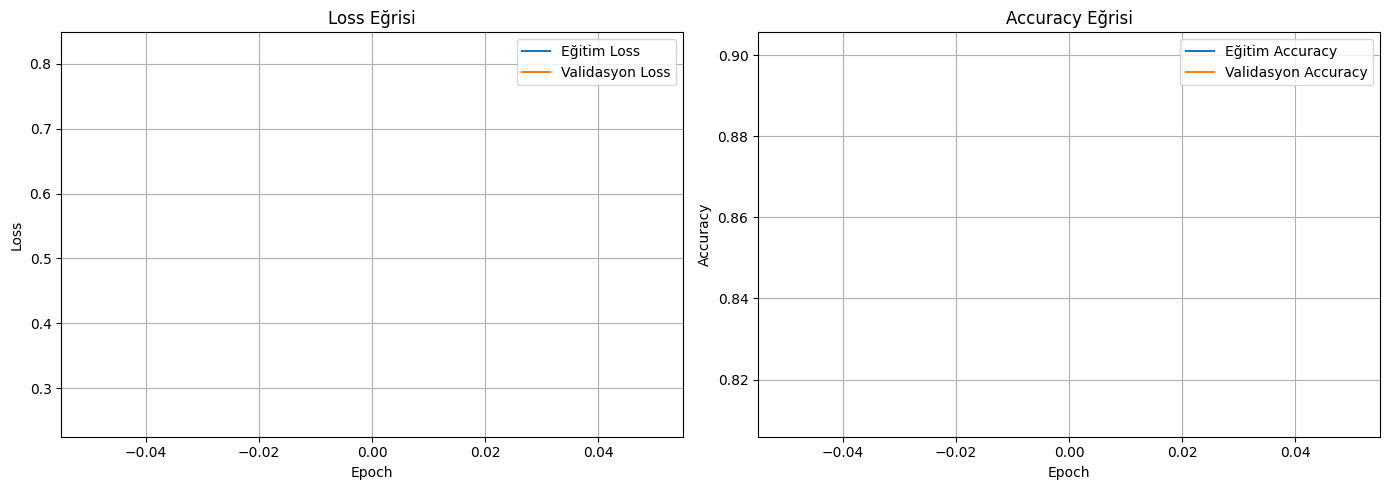

152/152 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.8336 - loss: 0.3728 - val_accuracy: 0.8104 - val_loss: 0.8200 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9608 - loss: 0.1105

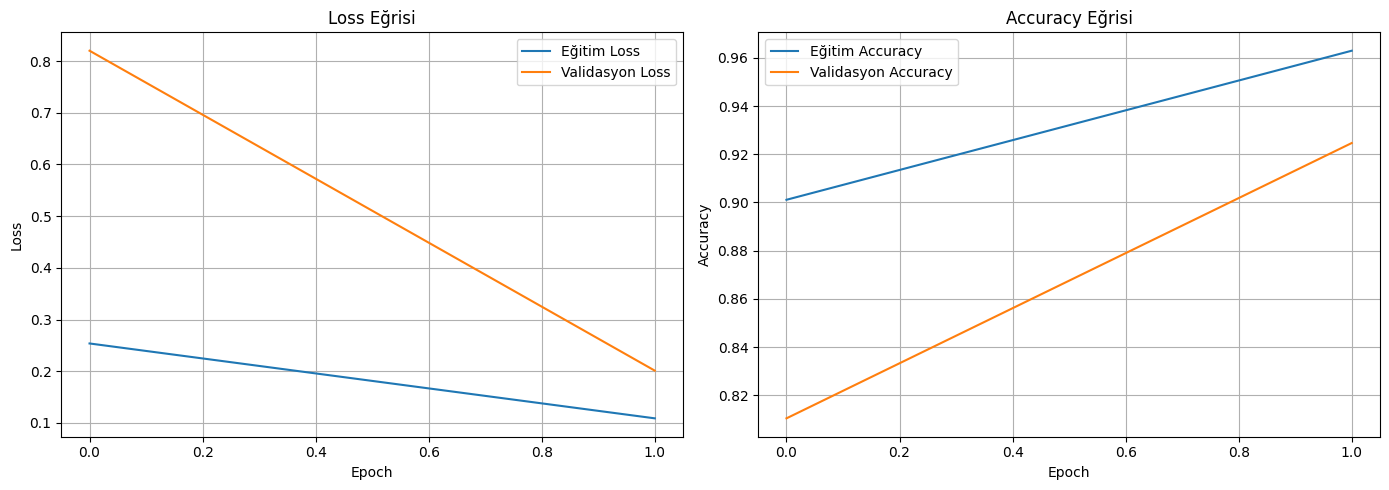

152/152 ━━━━━━━━━━━━━━━━━━━━ 643s 4s/step - accuracy: 0.9609 - loss: 0.1105 - val_accuracy: 0.9247 - val_loss: 0.2012 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9737 - loss: 0.0849

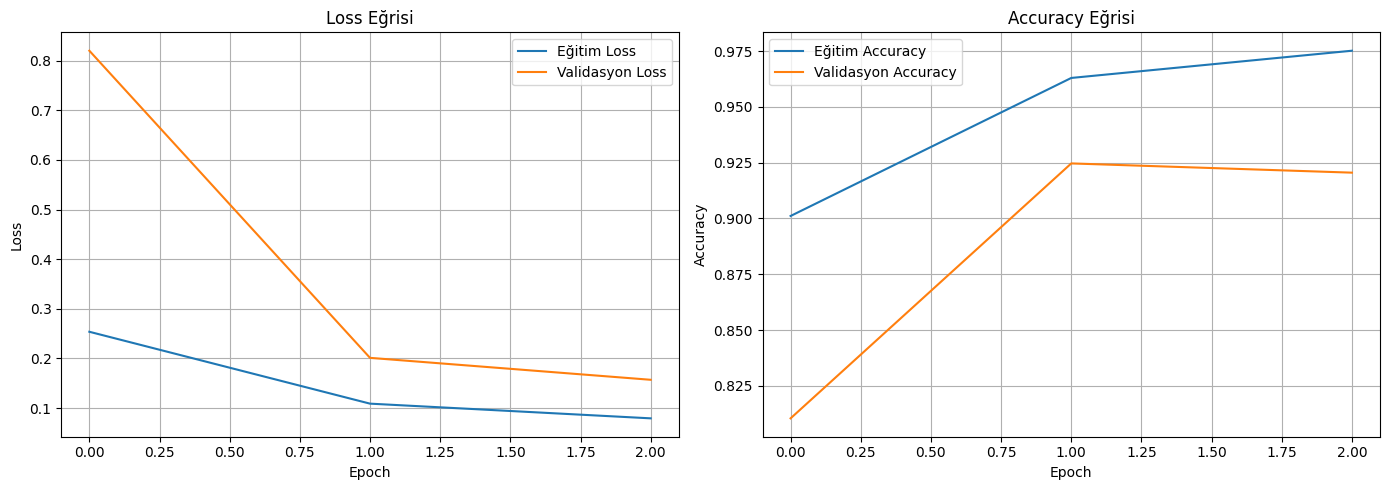

152/152 ━━━━━━━━━━━━━━━━━━━━ 640s 4s/step - accuracy: 0.9737 - loss: 0.0849 - val_accuracy: 0.9205 - val_loss: 0.1570 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8952 - loss: 0.2744

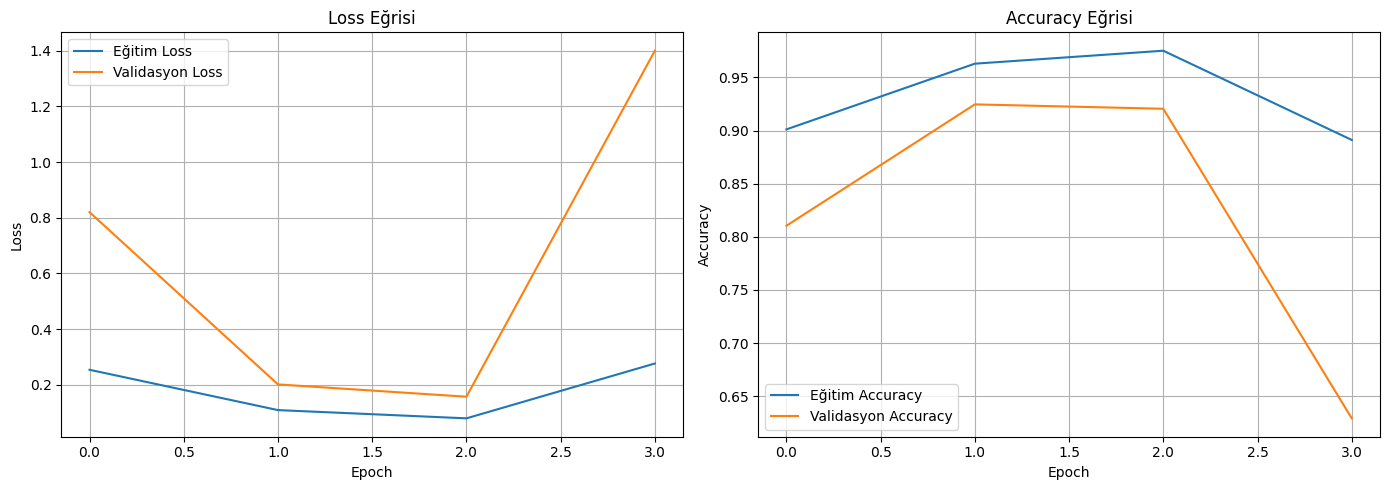

152/152 ━━━━━━━━━━━━━━━━━━━━ 630s 4s/step - accuracy: 0.8952 - loss: 0.2744 - val_accuracy: 0.6291 - val_loss: 1.4000 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9295 - loss: 0.1870

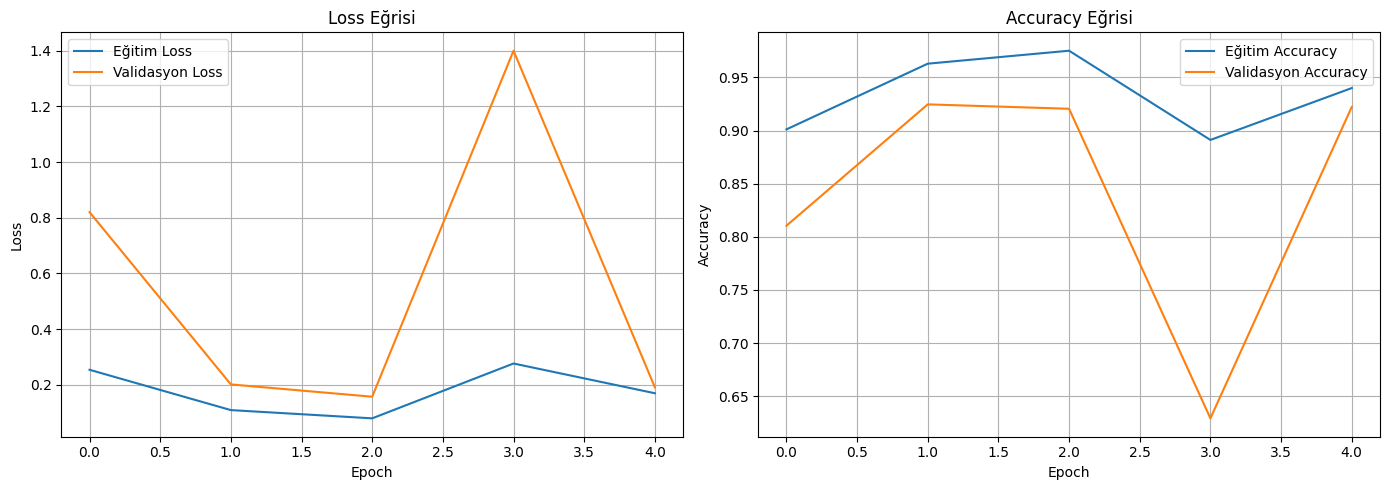

152/152 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.9296 - loss: 0.1869 - val_accuracy: 0.9222 - val_loss: 0.1911 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9548 - loss: 0.1341

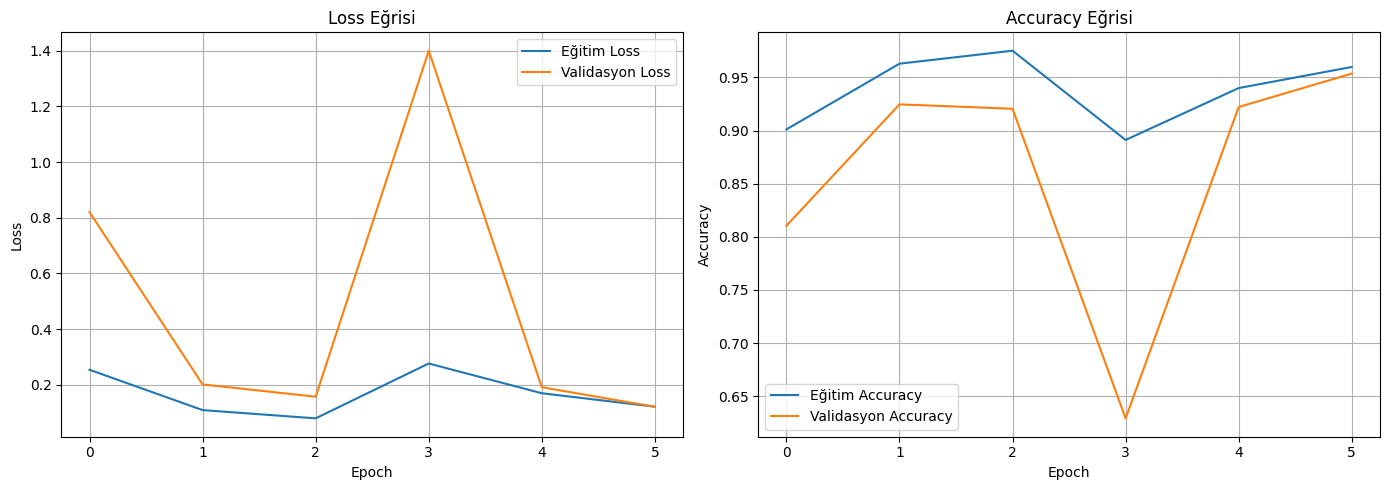

152/152 ━━━━━━━━━━━━━━━━━━━━ 641s 4s/step - accuracy: 0.9548 - loss: 0.1340 - val_accuracy: 0.9536 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9718 - loss: 0.0858

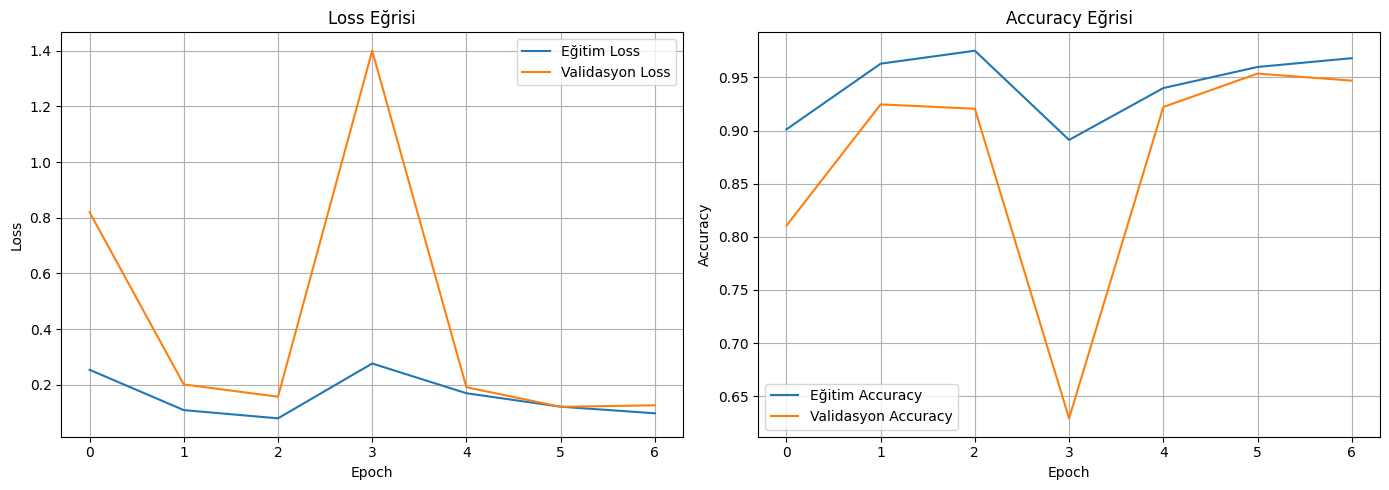

152/152 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.9718 - loss: 0.0859 - val_accuracy: 0.9470 - val_loss: 0.1261 - learning_rate: 0.0010
Epoch 8/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9654 - loss: 0.0962

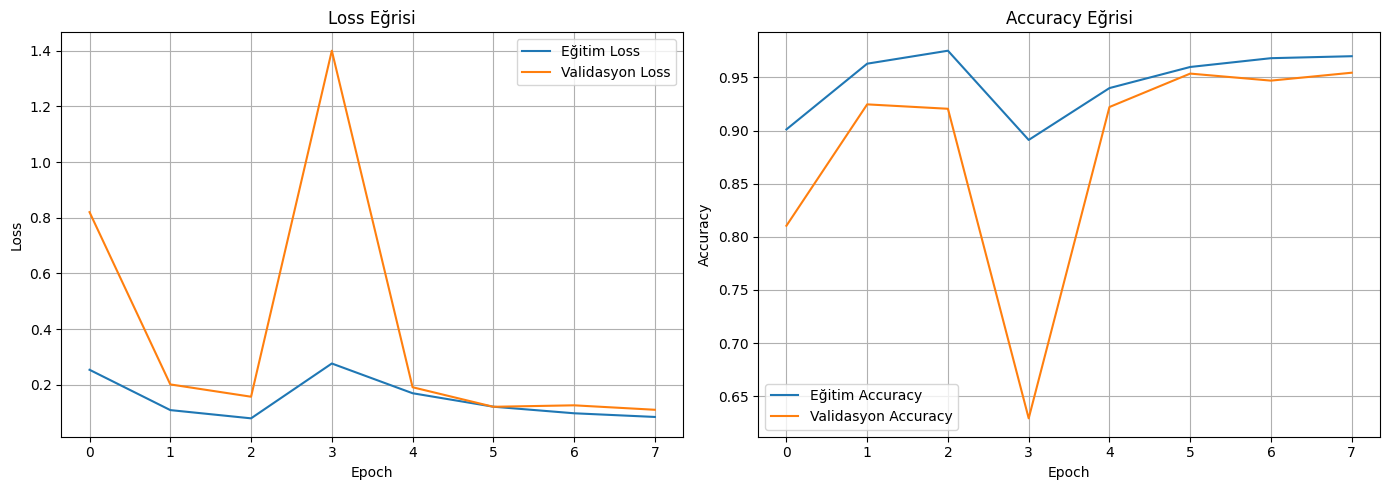

152/152 ━━━━━━━━━━━━━━━━━━━━ 671s 4s/step - accuracy: 0.9654 - loss: 0.0961 - val_accuracy: 0.9545 - val_loss: 0.1101 - learning_rate: 0.0010
Epoch 9/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9756 - loss: 0.0724

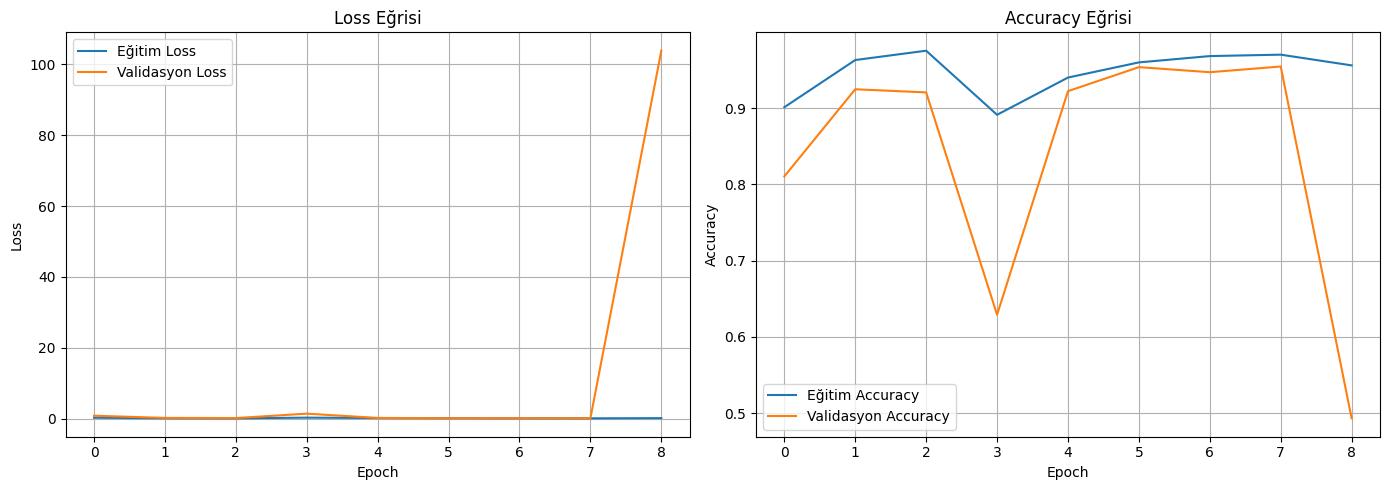

152/152 ━━━━━━━━━━━━━━━━━━━━ 679s 4s/step - accuracy: 0.9755 - loss: 0.0728 - val_accuracy: 0.4934 - val_loss: 103.8716 - learning_rate: 0.0010
Epoch 10/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8674 - loss: 0.3357

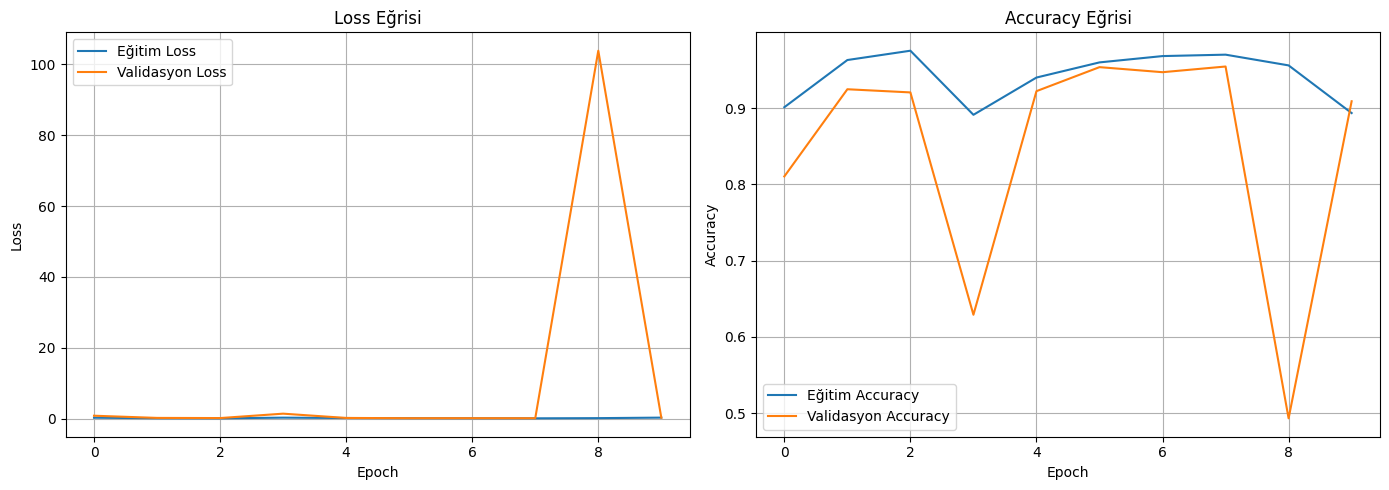

152/152 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.8676 - loss: 0.3354 - val_accuracy: 0.9089 - val_loss: 0.2487 - learning_rate: 0.0010
Epoch 11/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9278 - loss: 0.2030

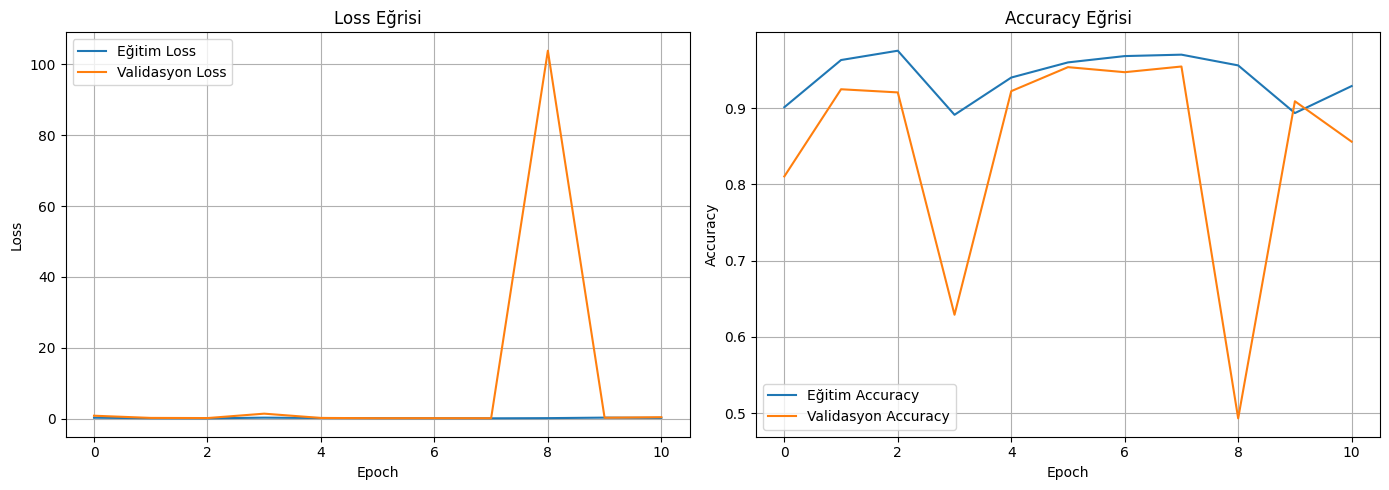

152/152 ━━━━━━━━━━━━━━━━━━━━ 658s 4s/step - accuracy: 0.9278 - loss: 0.2029 - val_accuracy: 0.8560 - val_loss: 0.4051 - learning_rate: 0.0010
Epoch 12/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9026 - loss: 0.2809

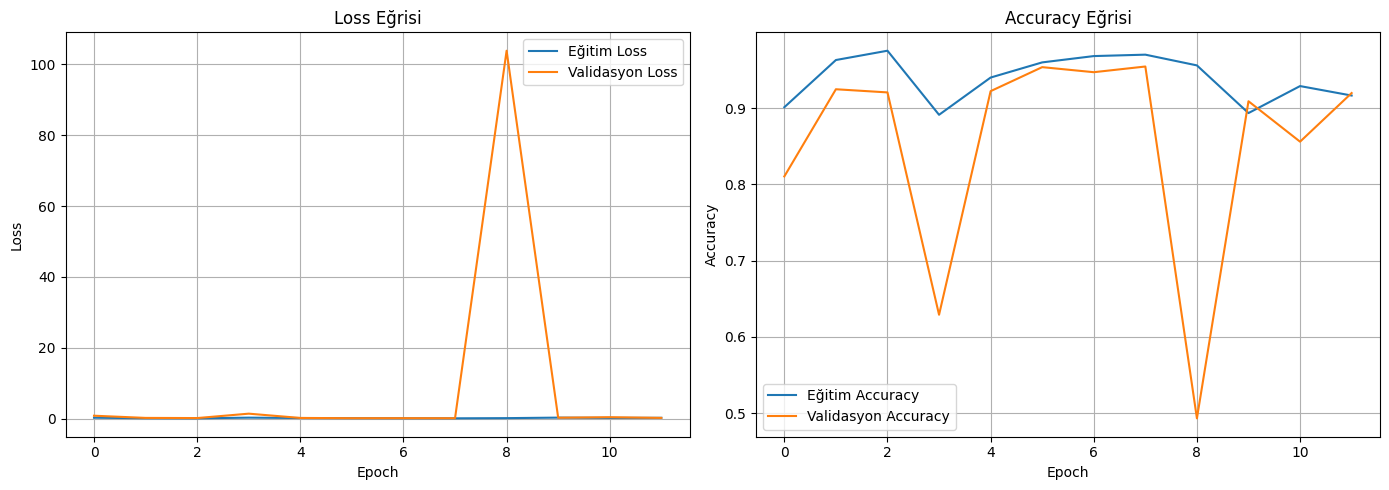

152/152 ━━━━━━━━━━━━━━━━━━━━ 688s 5s/step - accuracy: 0.9027 - loss: 0.2806 - val_accuracy: 0.9197 - val_loss: 0.2011 - learning_rate: 0.0010
Epoch 13/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9434 - loss: 0.1562

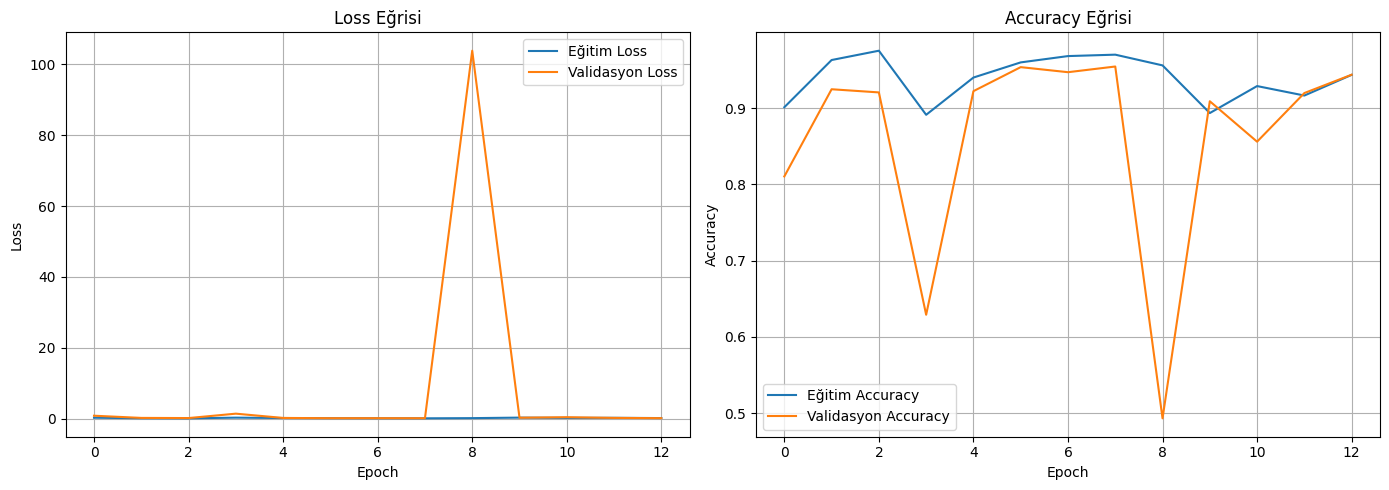

152/152 ━━━━━━━━━━━━━━━━━━━━ 713s 5s/step - accuracy: 0.9434 - loss: 0.1562 - val_accuracy: 0.9437 - val_loss: 0.1297 - learning_rate: 0.0010
Epoch 14/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9643 - loss: 0.1049

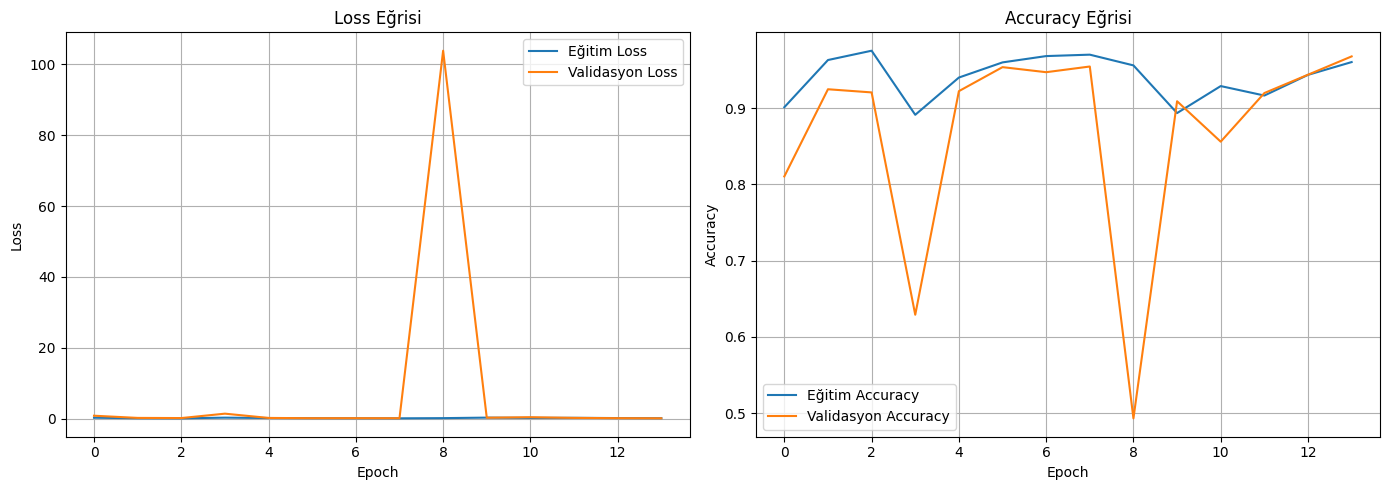

152/152 ━━━━━━━━━━━━━━━━━━━━ 718s 5s/step - accuracy: 0.9643 - loss: 0.1049 - val_accuracy: 0.9677 - val_loss: 0.0924 - learning_rate: 0.0010
Epoch 15/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9548 - loss: 0.1363

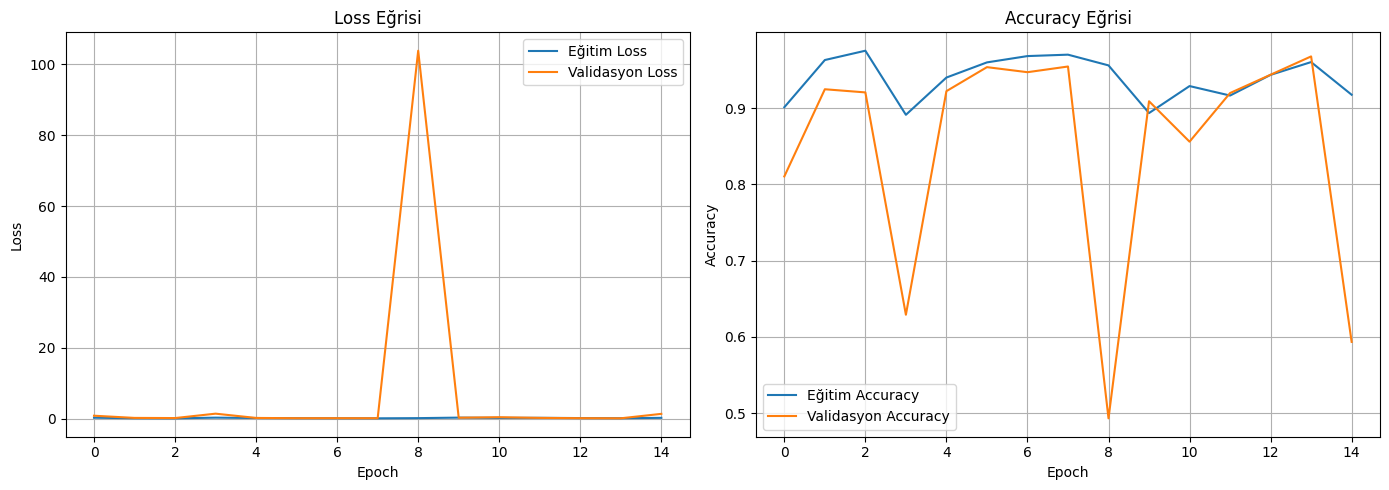

152/152 ━━━━━━━━━━━━━━━━━━━━ 716s 5s/step - accuracy: 0.9546 - loss: 0.1369 - val_accuracy: 0.5935 - val_loss: 1.3450 - learning_rate: 0.0010
Epoch 16/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8861 - loss: 0.2690

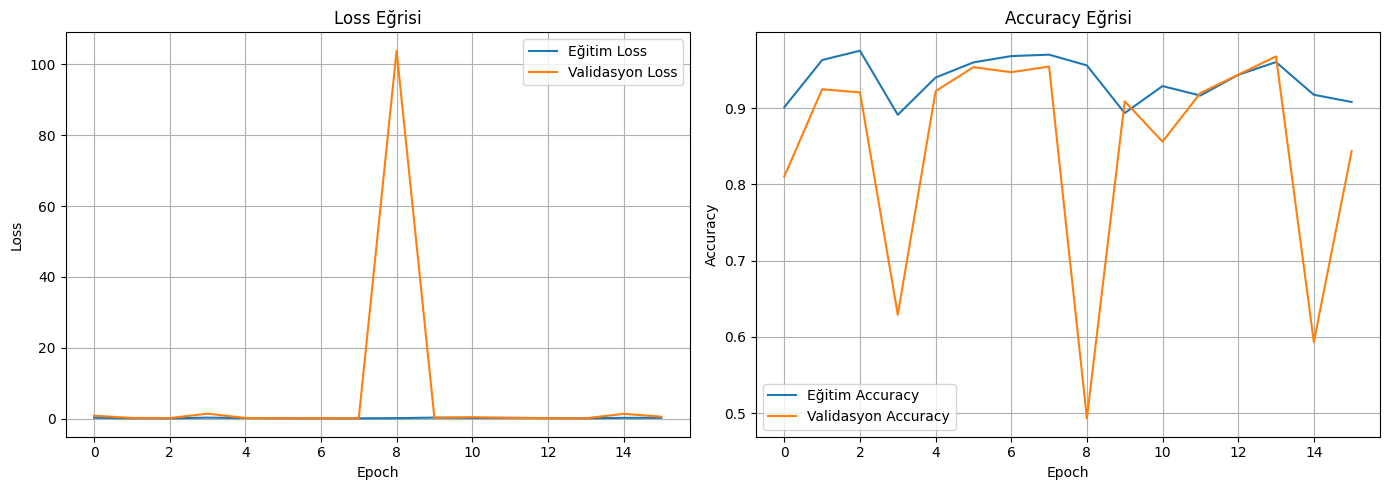

152/152 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.8863 - loss: 0.2687 - val_accuracy: 0.8435 - val_loss: 0.5589 - learning_rate: 0.0010
Epoch 17/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9143 - loss: 0.2311

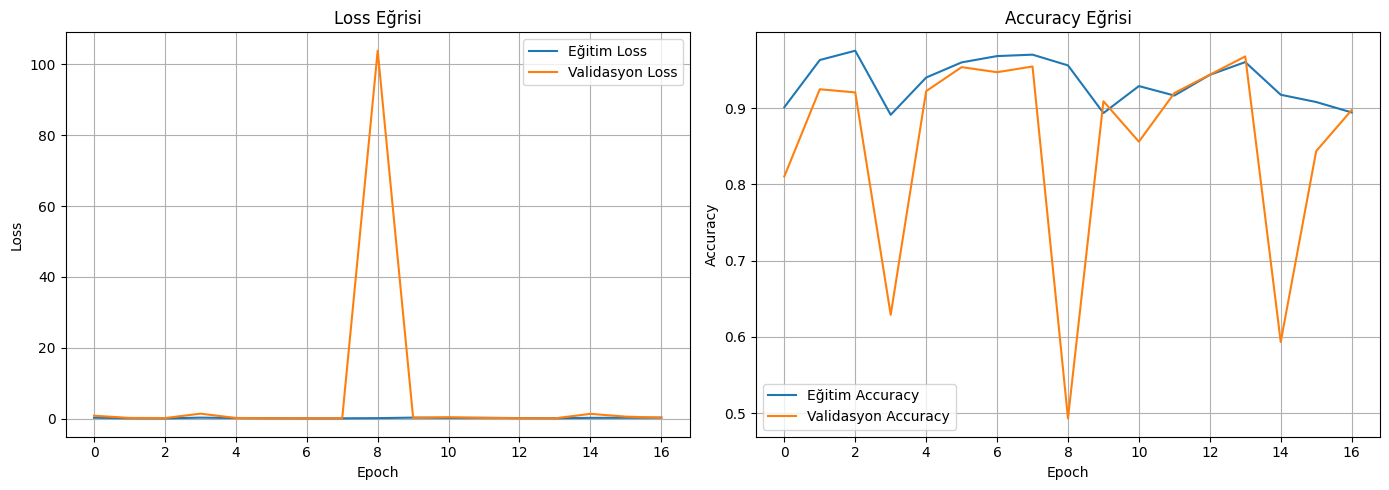

152/152 ━━━━━━━━━━━━━━━━━━━━ 681s 4s/step - accuracy: 0.9142 - loss: 0.2313 - val_accuracy: 0.8974 - val_loss: 0.2747 - learning_rate: 0.0010
Epoch 18/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9123 - loss: 0.2154

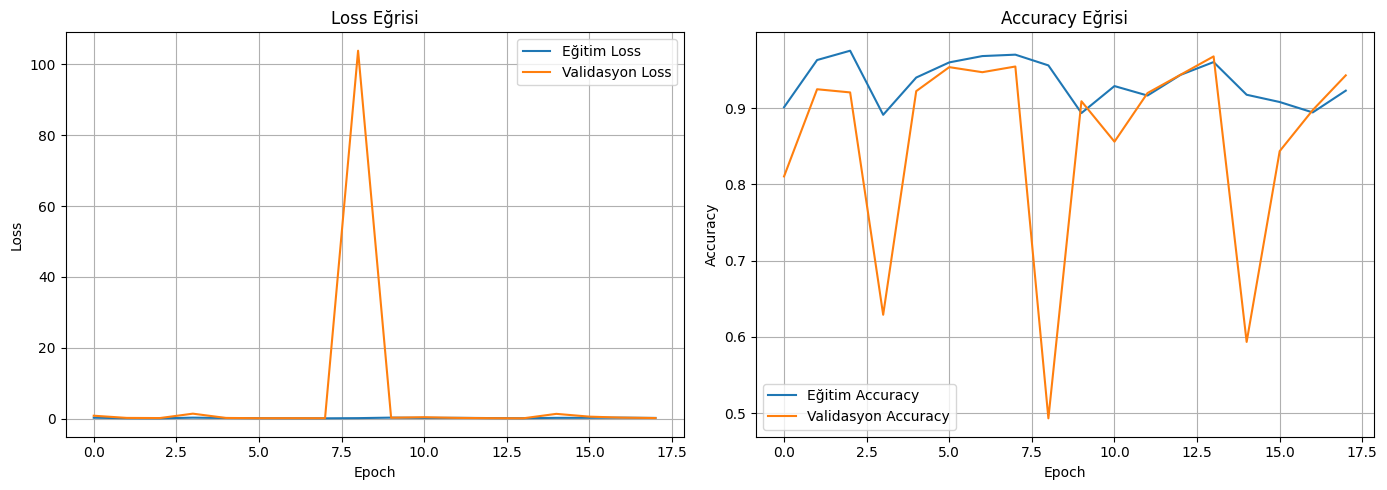

152/152 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9124 - loss: 0.2153 - val_accuracy: 0.9429 - val_loss: 0.1617 - learning_rate: 0.0010
Epoch 19/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9376 - loss: 0.1742

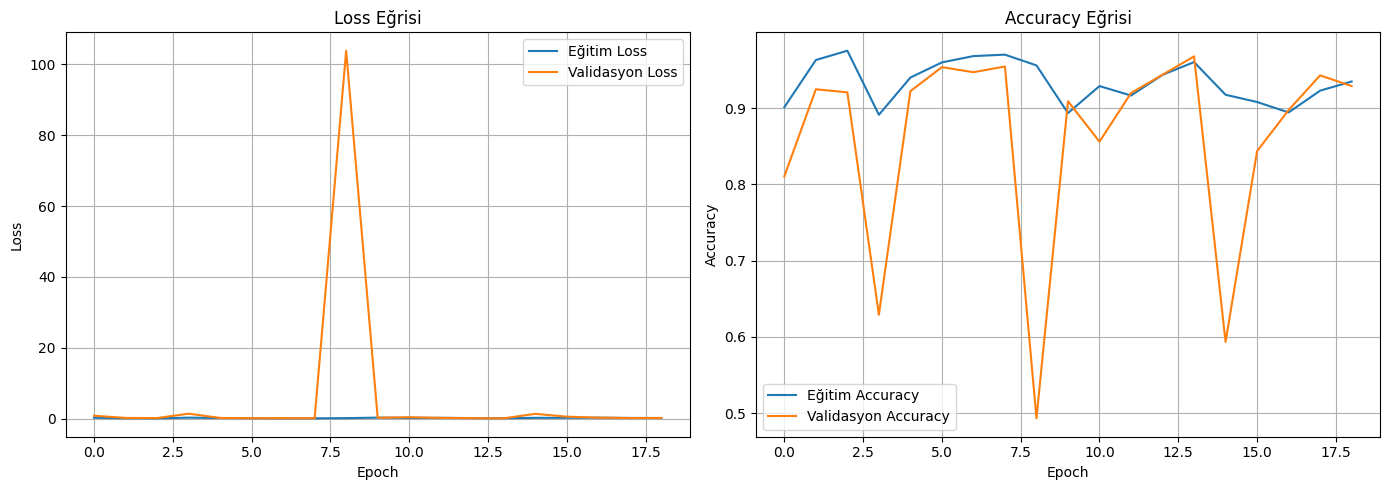

152/152 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9376 - loss: 0.1742 - val_accuracy: 0.9288 - val_loss: 0.1738 - learning_rate: 0.0010
Epoch 20/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9378 - loss: 0.1582

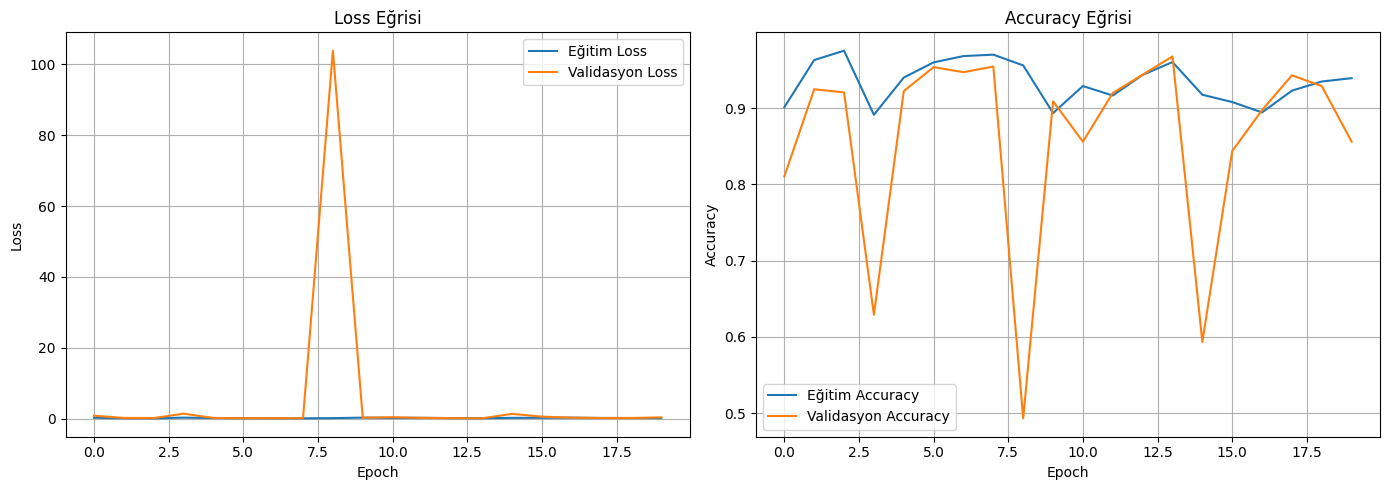

152/152 ━━━━━━━━━━━━━━━━━━━━ 685s 5s/step - accuracy: 0.9378 - loss: 0.1582 - val_accuracy: 0.8560 - val_loss: 0.3548 - learning_rate: 0.0010
Epoch 21/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9427 - loss: 0.1641

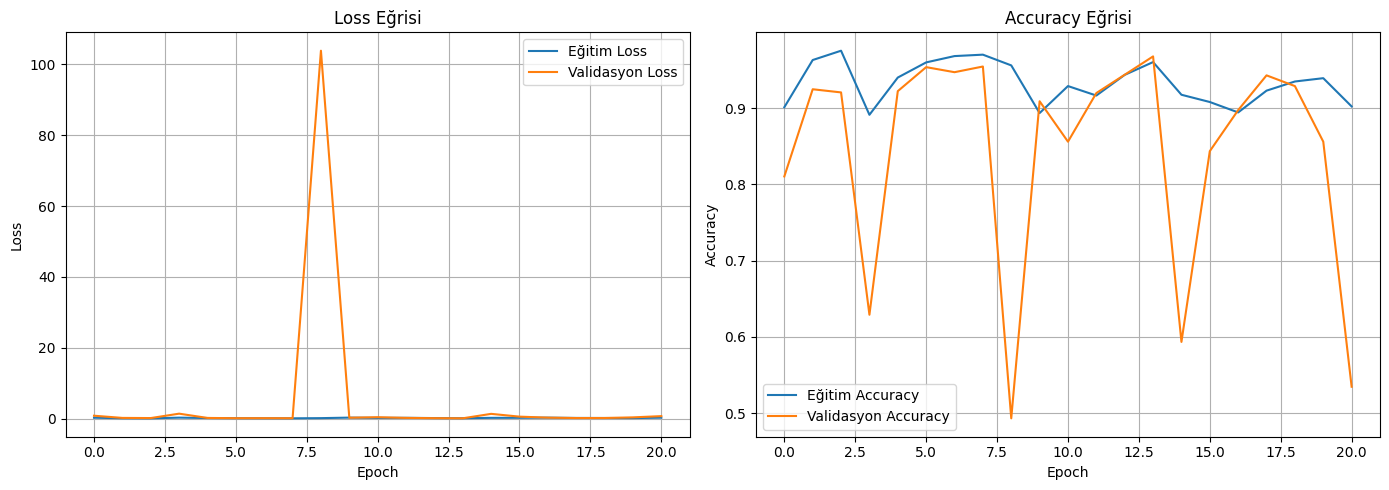

152/152 ━━━━━━━━━━━━━━━━━━━━ 688s 5s/step - accuracy: 0.9424 - loss: 0.1648 - val_accuracy: 0.5348 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 22/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8423 - loss: 0.3917

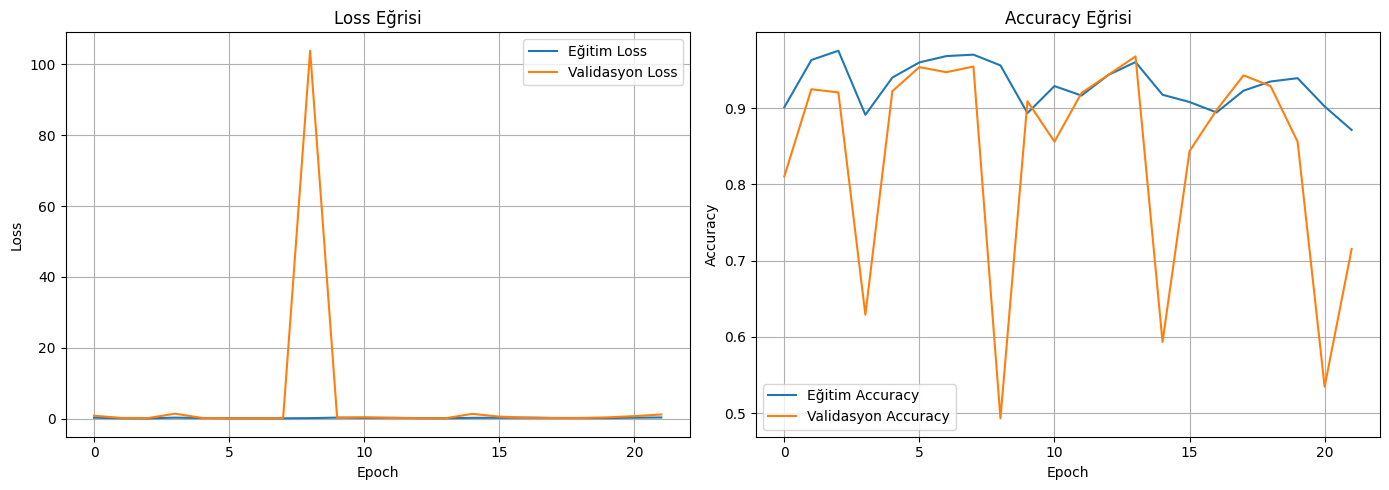

152/152 ━━━━━━━━━━━━━━━━━━━━ 687s 5s/step - accuracy: 0.8425 - loss: 0.3913 - val_accuracy: 0.7152 - val_loss: 1.1665 - learning_rate: 0.0010
Epoch 23/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9190 - loss: 0.2062

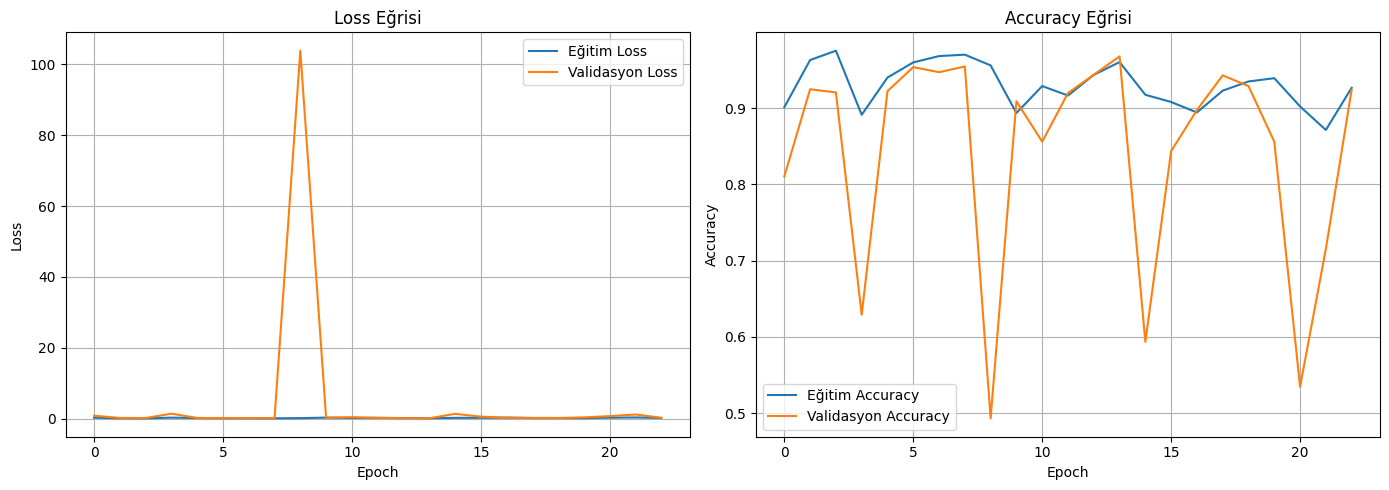

152/152 ━━━━━━━━━━━━━━━━━━━━ 693s 5s/step - accuracy: 0.9191 - loss: 0.2061 - val_accuracy: 0.9238 - val_loss: 0.2434 - learning_rate: 0.0010
Epoch 24/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9476 - loss: 0.1447

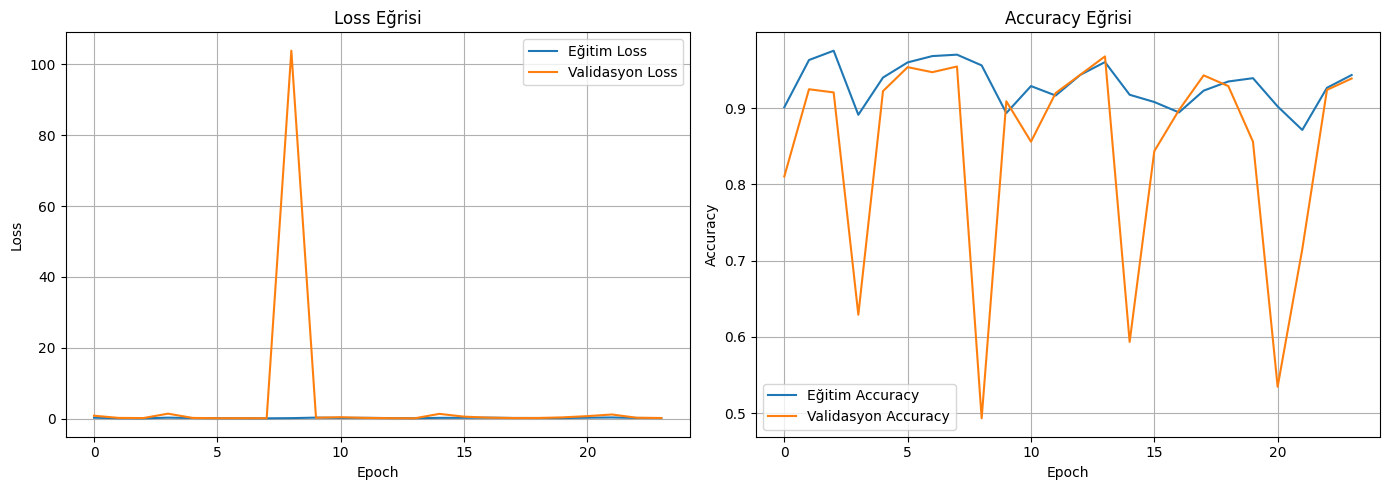

152/152 ━━━━━━━━━━━━━━━━━━━━ 686s 5s/step - accuracy: 0.9476 - loss: 0.1448 - val_accuracy: 0.9387 - val_loss: 0.1723 - learning_rate: 0.0010
Epoch 25/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9498 - loss: 0.1394

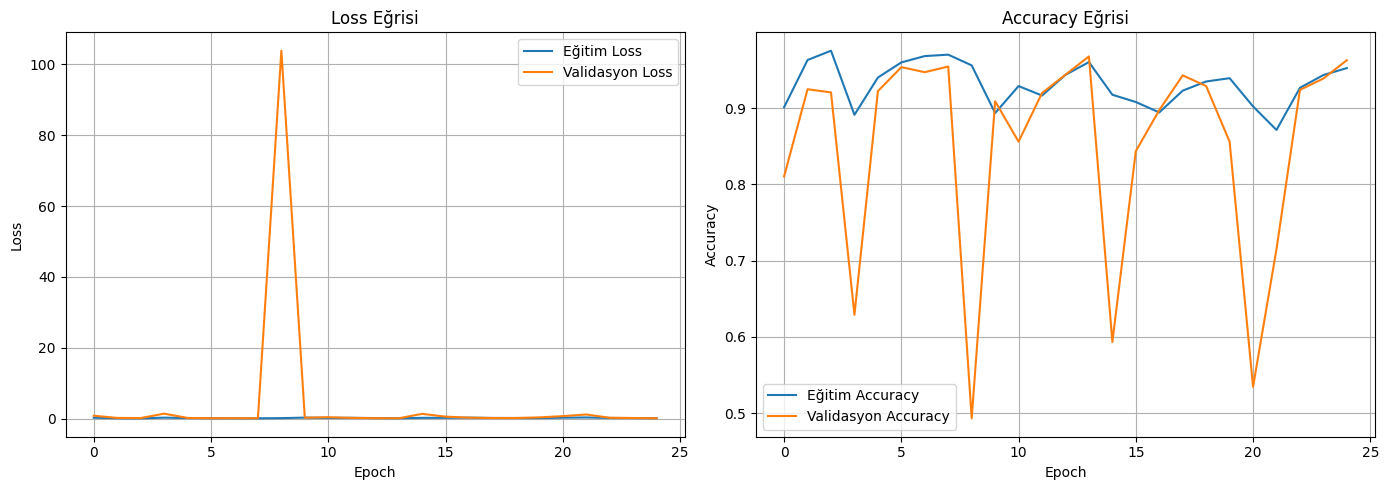

152/152 ━━━━━━━━━━━━━━━━━━━━ 690s 5s/step - accuracy: 0.9498 - loss: 0.1393 - val_accuracy: 0.9627 - val_loss: 0.1067 - learning_rate: 1.0000e-04
Epoch 26/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9594 - loss: 0.1205

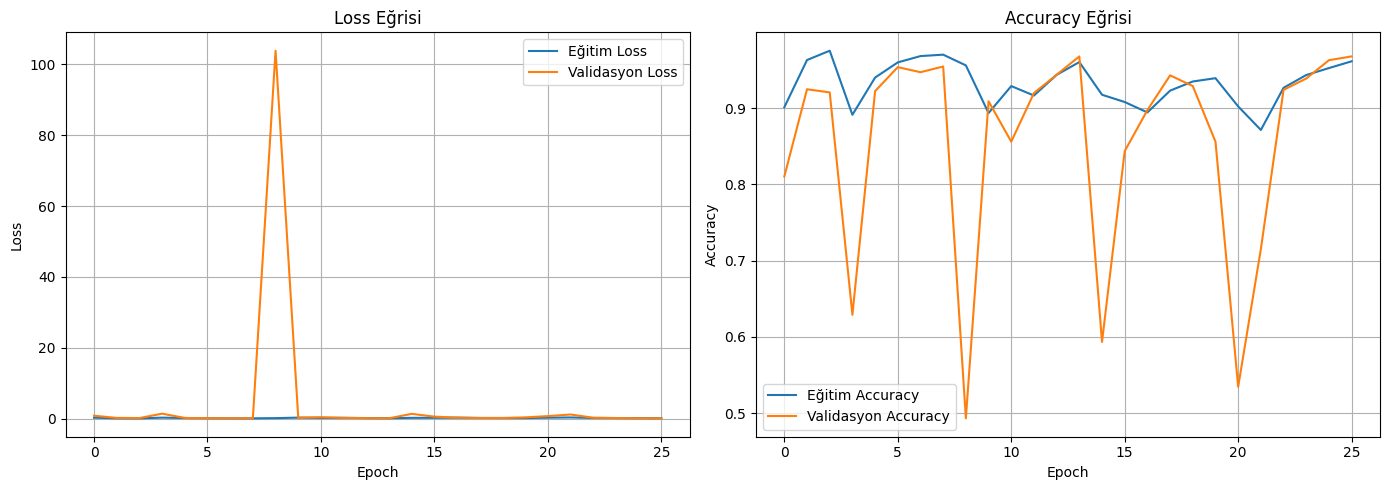

152/152 ━━━━━━━━━━━━━━━━━━━━ 688s 5s/step - accuracy: 0.9594 - loss: 0.1204 - val_accuracy: 0.9677 - val_loss: 0.0891 - learning_rate: 1.0000e-04
Epoch 27/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9650 - loss: 0.1081

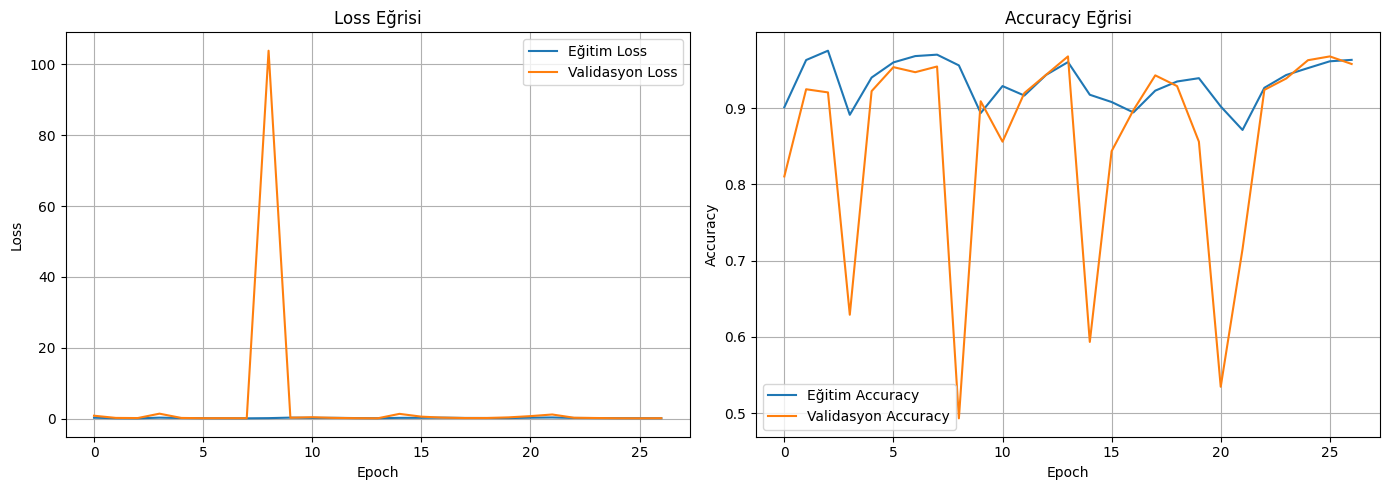

152/152 ━━━━━━━━━━━━━━━━━━━━ 690s 5s/step - accuracy: 0.9650 - loss: 0.1081 - val_accuracy: 0.9578 - val_loss: 0.1165 - learning_rate: 1.0000e-04
Epoch 28/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9713 - loss: 0.0882

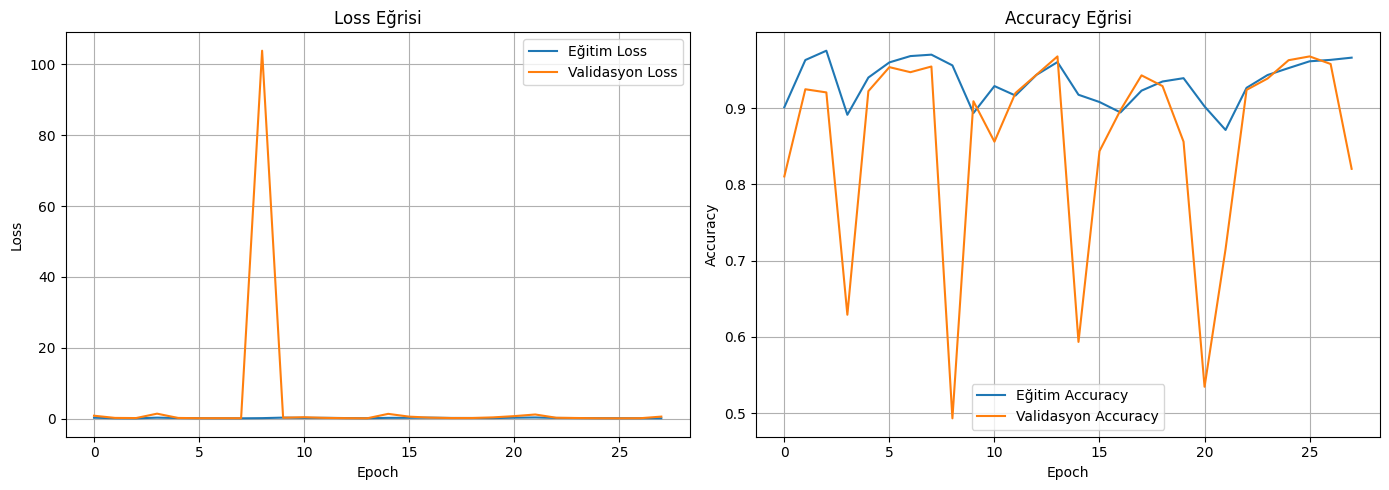

152/152 ━━━━━━━━━━━━━━━━━━━━ 690s 5s/step - accuracy: 0.9712 - loss: 0.0883 - val_accuracy: 0.8204 - val_loss: 0.5705 - learning_rate: 1.0000e-04
Epoch 29/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9336 - loss: 0.1871

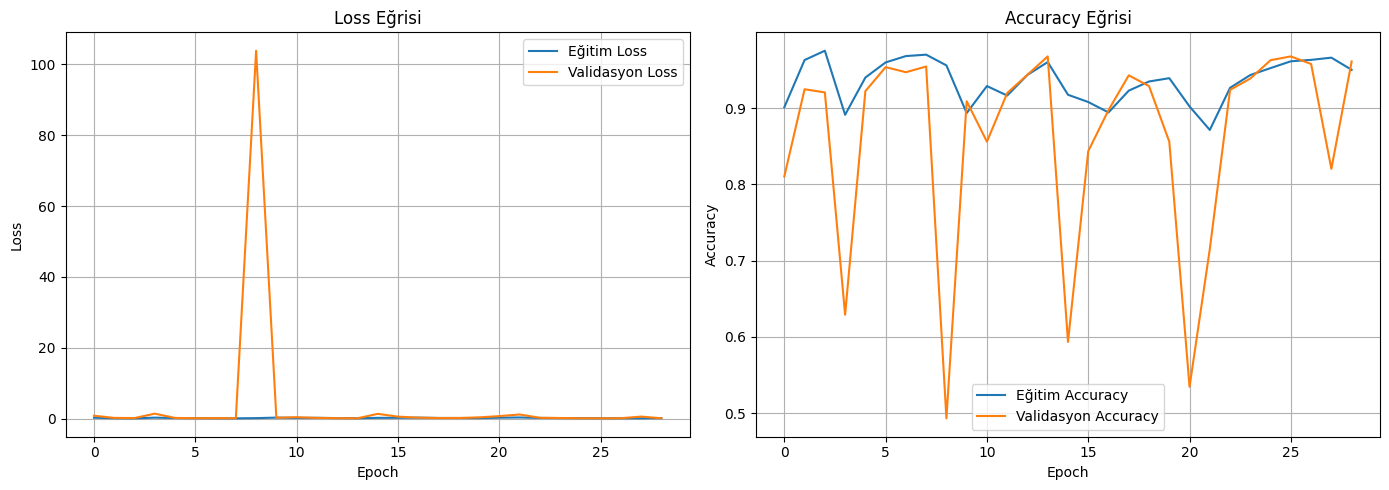

152/152 ━━━━━━━━━━━━━━━━━━━━ 691s 5s/step - accuracy: 0.9337 - loss: 0.1869 - val_accuracy: 0.9611 - val_loss: 0.1090 - learning_rate: 1.0000e-04
Epoch 30/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9600 - loss: 0.1109

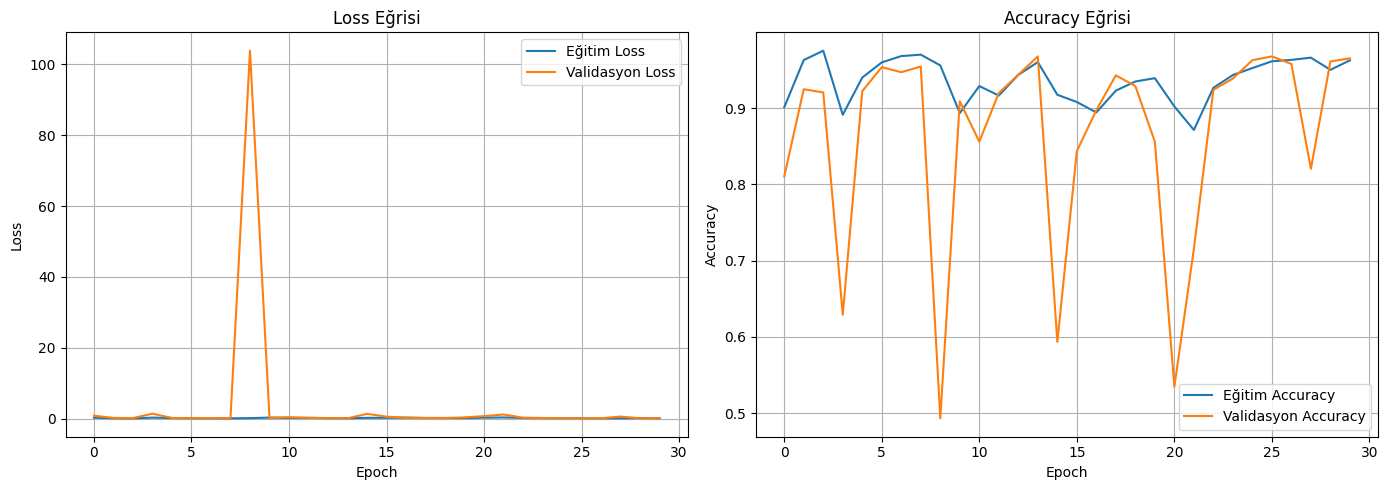

152/152 ━━━━━━━━━━━━━━━━━━━━ 690s 5s/step - accuracy: 0.9600 - loss: 0.1109 - val_accuracy: 0.9652 - val_loss: 0.0857 - learning_rate: 1.0000e-04
Epoch 31/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9739 - loss: 0.0952

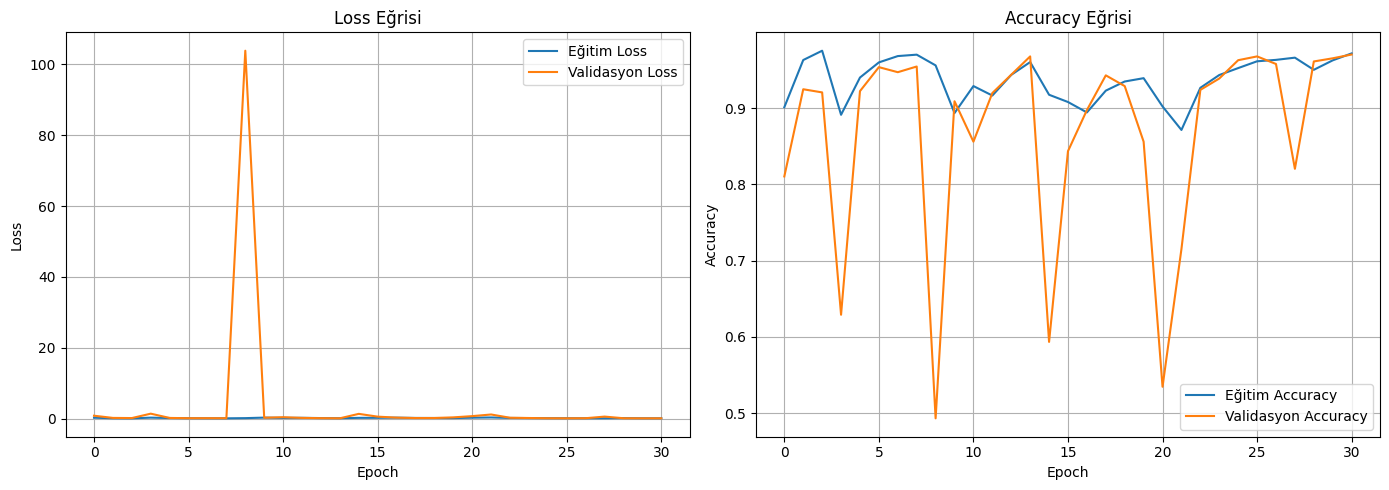

152/152 ━━━━━━━━━━━━━━━━━━━━ 693s 5s/step - accuracy: 0.9739 - loss: 0.0952 - val_accuracy: 0.9702 - val_loss: 0.0876 - learning_rate: 1.0000e-04
Epoch 32/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9718 - loss: 0.0782

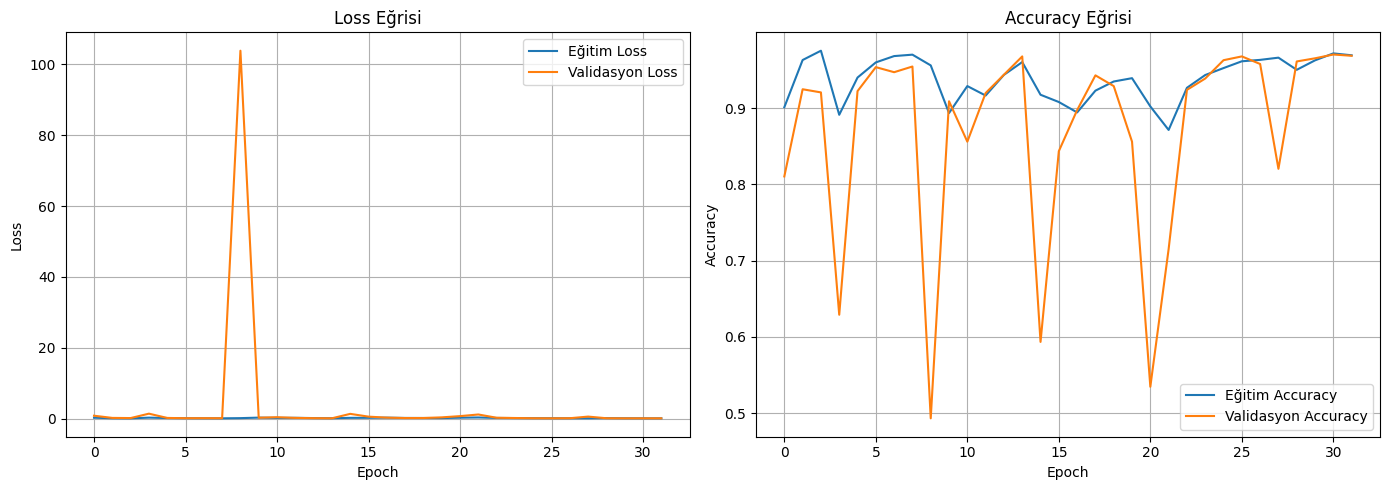

152/152 ━━━━━━━━━━━━━━━━━━━━ 693s 5s/step - accuracy: 0.9718 - loss: 0.0782 - val_accuracy: 0.9685 - val_loss: 0.0843 - learning_rate: 1.0000e-04
Epoch 33/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9711 - loss: 0.0816

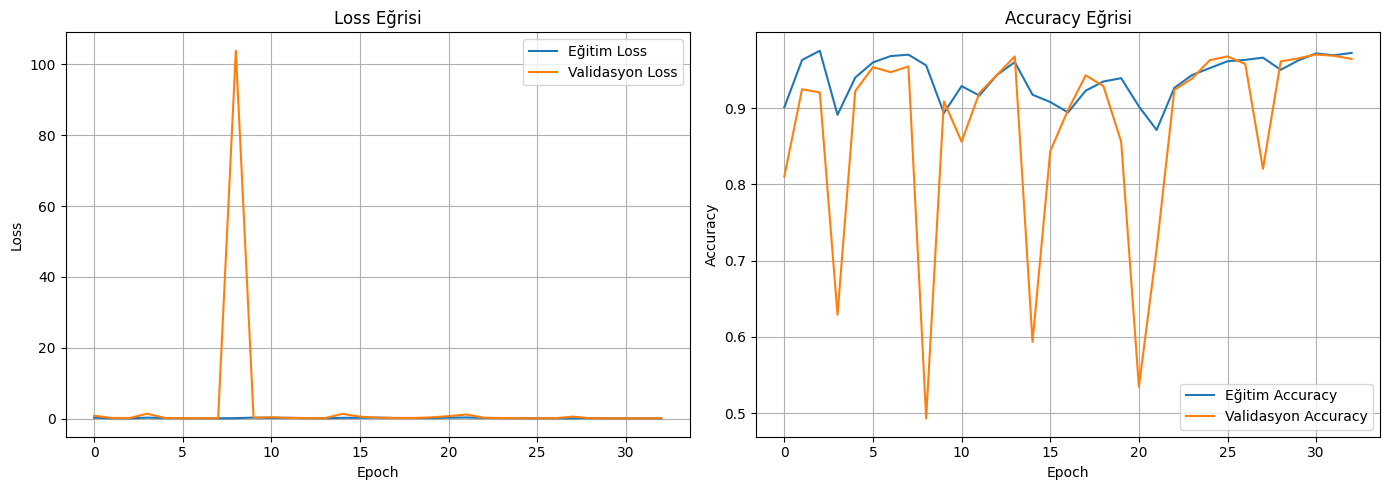

152/152 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.9711 - loss: 0.0816 - val_accuracy: 0.9644 - val_loss: 0.1000 - learning_rate: 1.0000e-04
Epoch 34/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9658 - loss: 0.0930

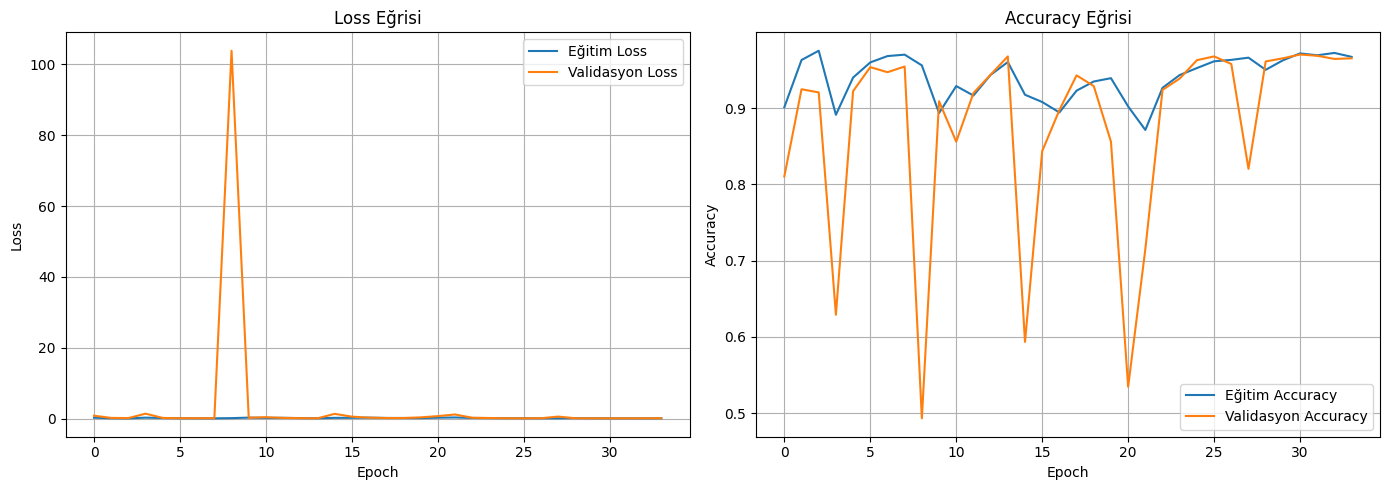

152/152 ━━━━━━━━━━━━━━━━━━━━ 692s 5s/step - accuracy: 0.9658 - loss: 0.0930 - val_accuracy: 0.9652 - val_loss: 0.1026 - learning_rate: 1.0000e-04
Epoch 35/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9552 - loss: 0.1276

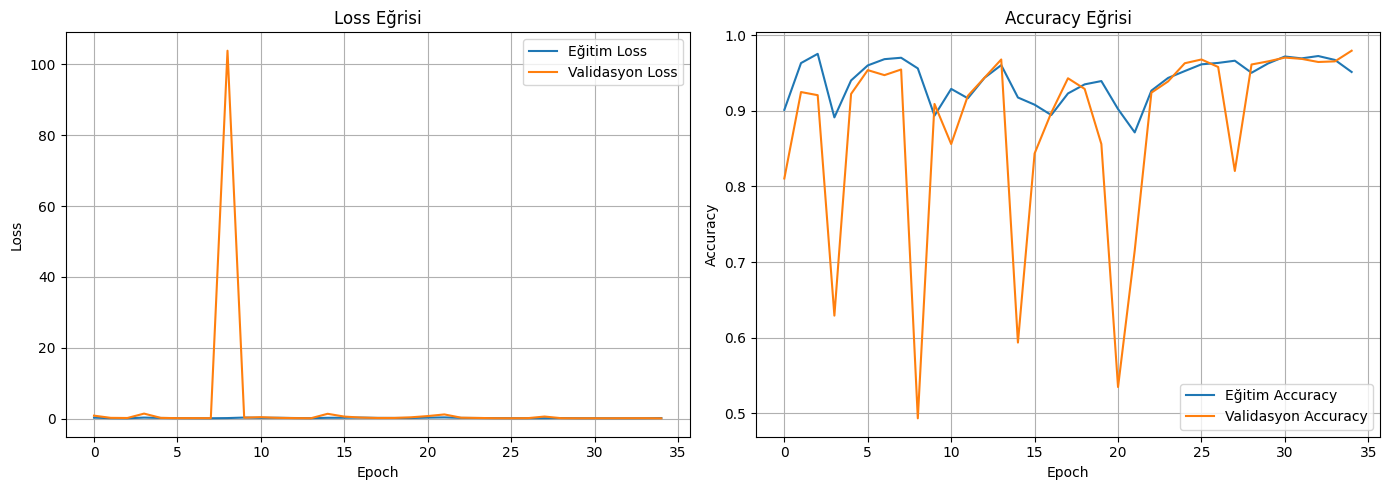

152/152 ━━━━━━━━━━━━━━━━━━━━ 715s 5s/step - accuracy: 0.9552 - loss: 0.1277 - val_accuracy: 0.9793 - val_loss: 0.0623 - learning_rate: 1.0000e-04
Epoch 36/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9628 - loss: 0.1032

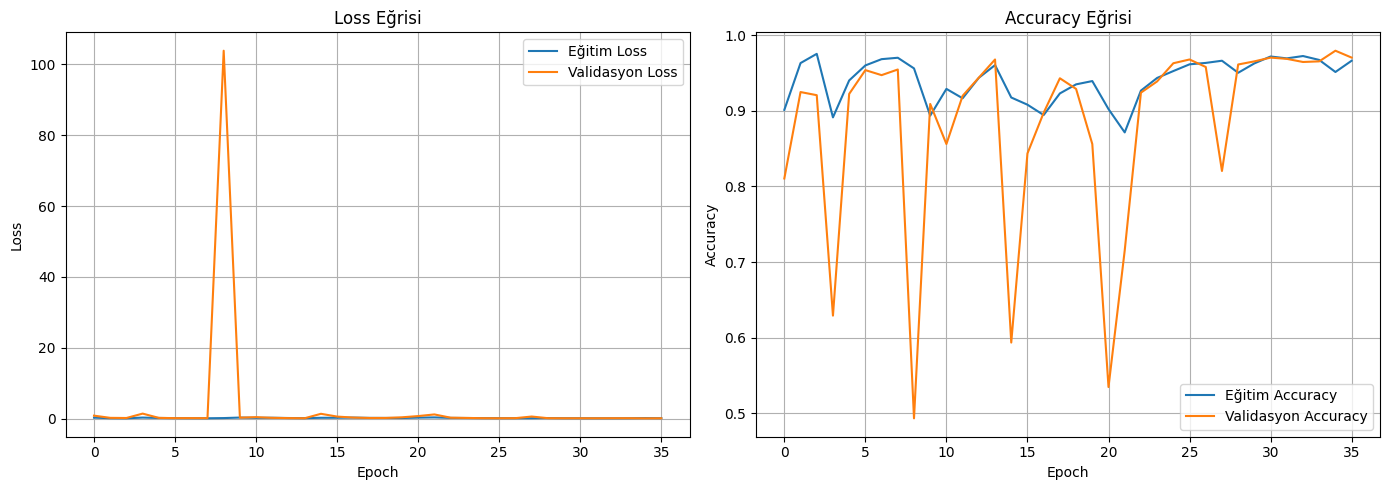

152/152 ━━━━━━━━━━━━━━━━━━━━ 750s 5s/step - accuracy: 0.9628 - loss: 0.1032 - val_accuracy: 0.9702 - val_loss: 0.0801 - learning_rate: 1.0000e-04
Epoch 37/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9697 - loss: 0.0838

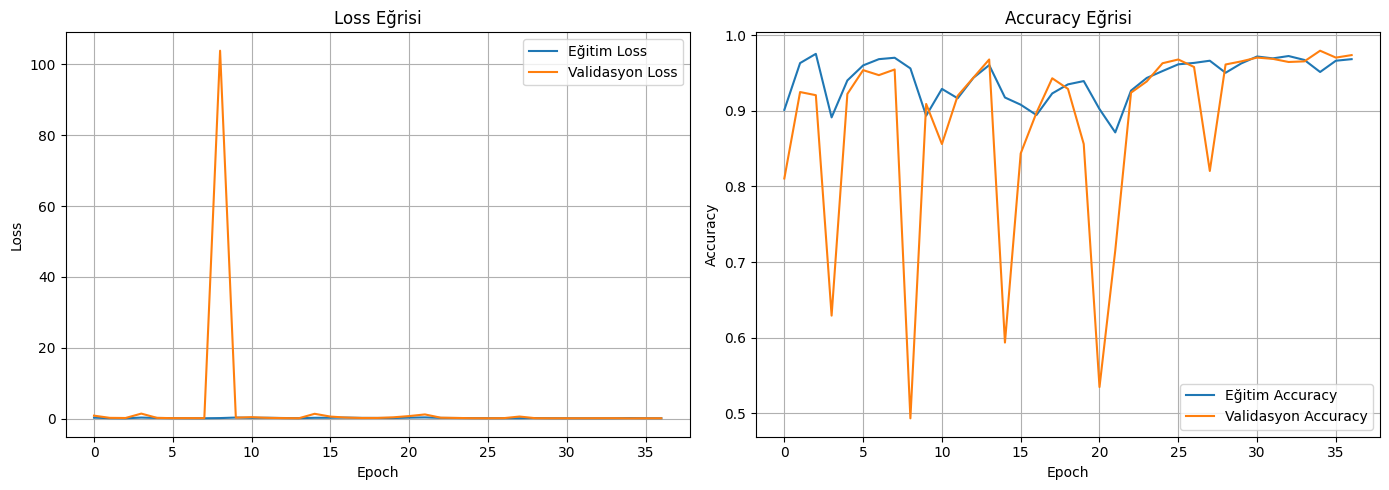

152/152 ━━━━━━━━━━━━━━━━━━━━ 1331s 9s/step - accuracy: 0.9697 - loss: 0.0838 - val_accuracy: 0.9735 - val_loss: 0.0841 - learning_rate: 1.0000e-04
Epoch 38/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9724 - loss: 0.0813

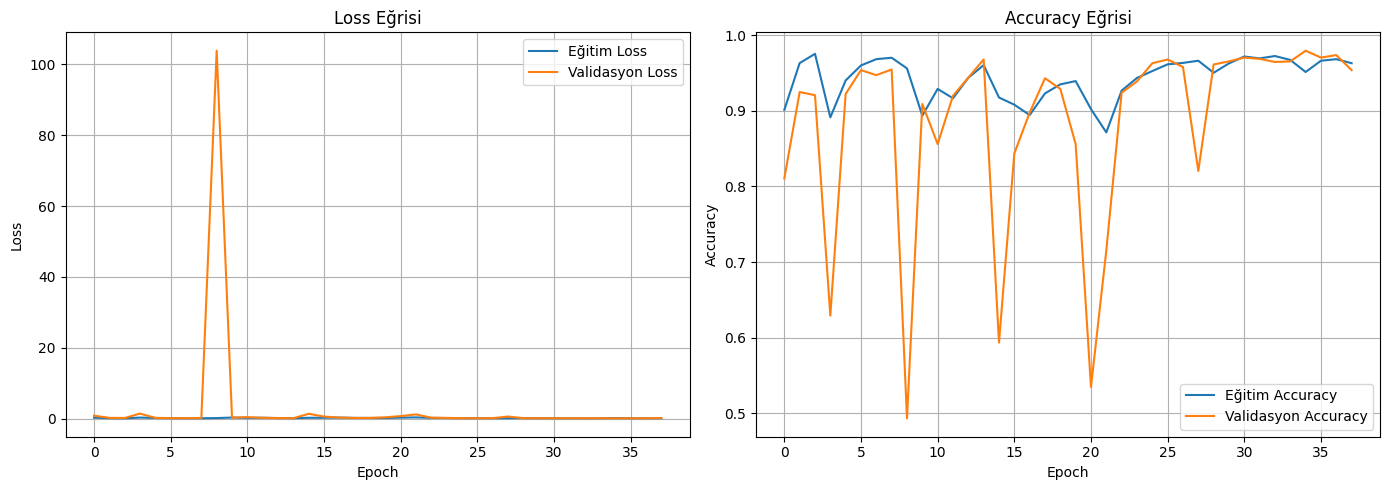

152/152 ━━━━━━━━━━━━━━━━━━━━ 812s 5s/step - accuracy: 0.9723 - loss: 0.0814 - val_accuracy: 0.9536 - val_loss: 0.1527 - learning_rate: 1.0000e-04
Epoch 39/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9652 - loss: 0.0929 

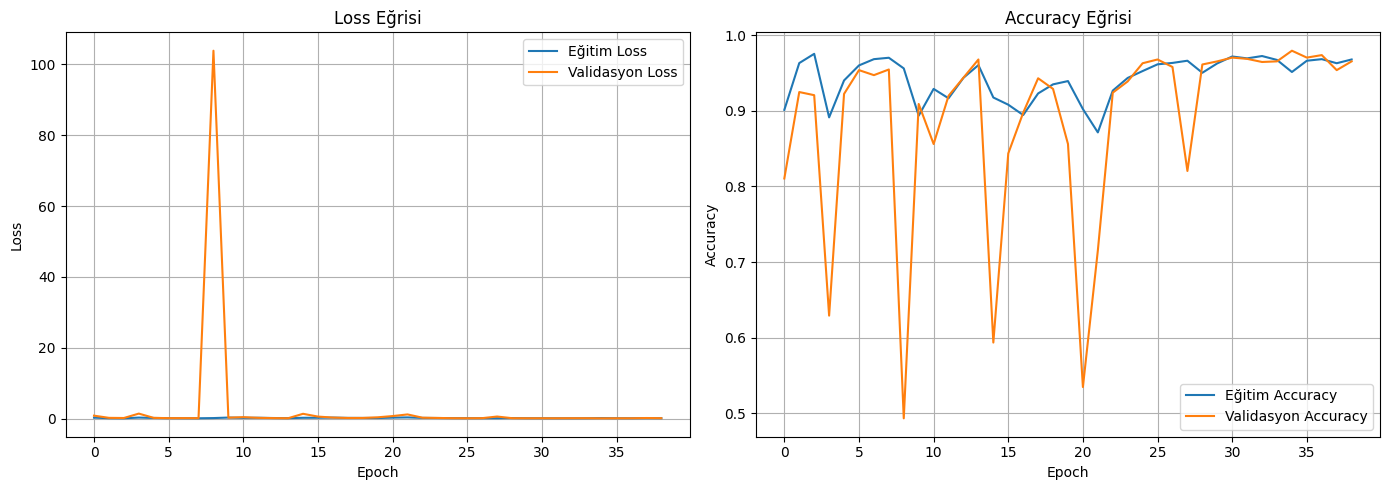

152/152 ━━━━━━━━━━━━━━━━━━━━ 1862s 12s/step - accuracy: 0.9652 - loss: 0.0929 - val_accuracy: 0.9652 - val_loss: 0.1038 - learning_rate: 1.0000e-04
Epoch 40/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9730 - loss: 0.0867

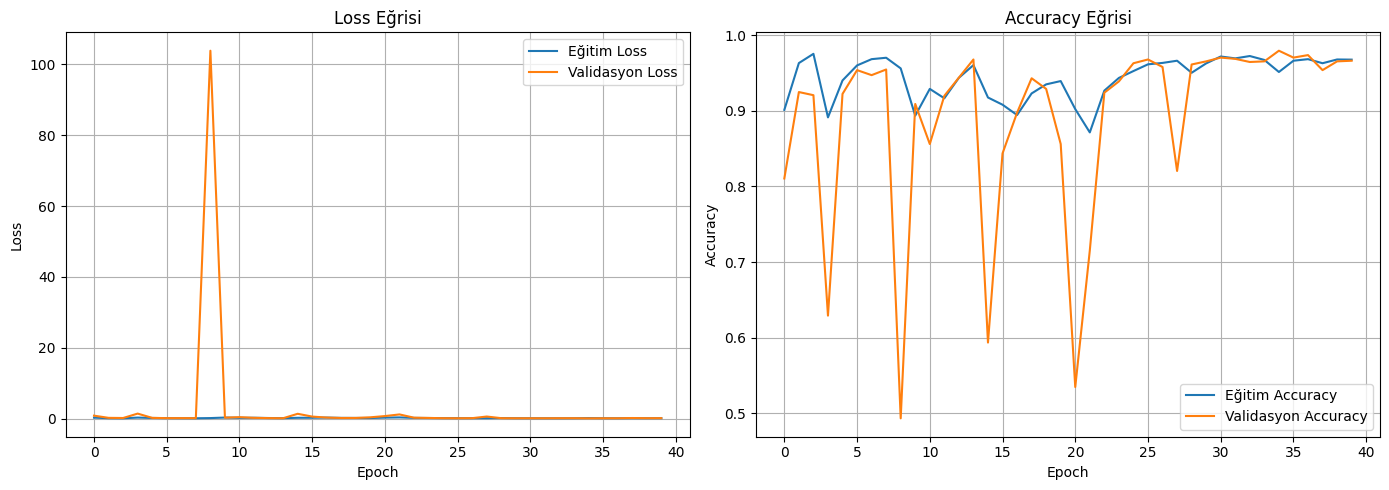

152/152 ━━━━━━━━━━━━━━━━━━━━ 800s 5s/step - accuracy: 0.9729 - loss: 0.0868 - val_accuracy: 0.9661 - val_loss: 0.1156 - learning_rate: 1.0000e-04
Epoch 41/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9656 - loss: 0.0937 

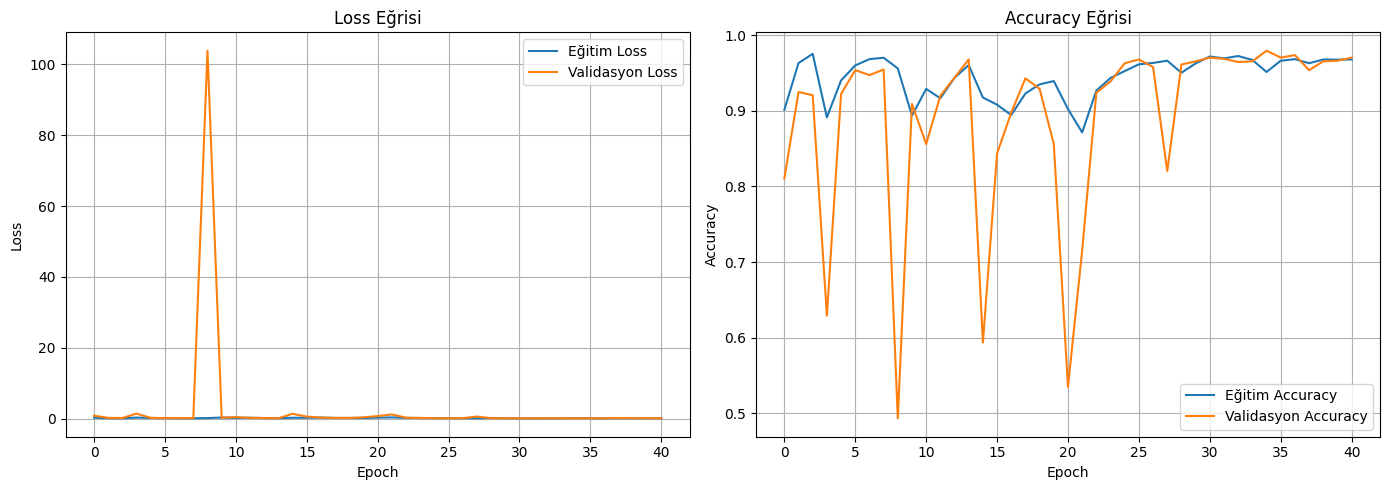

152/152 ━━━━━━━━━━━━━━━━━━━━ 1808s 12s/step - accuracy: 0.9657 - loss: 0.0937 - val_accuracy: 0.9702 - val_loss: 0.0911 - learning_rate: 1.0000e-04
Epoch 42/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9775 - loss: 0.0783

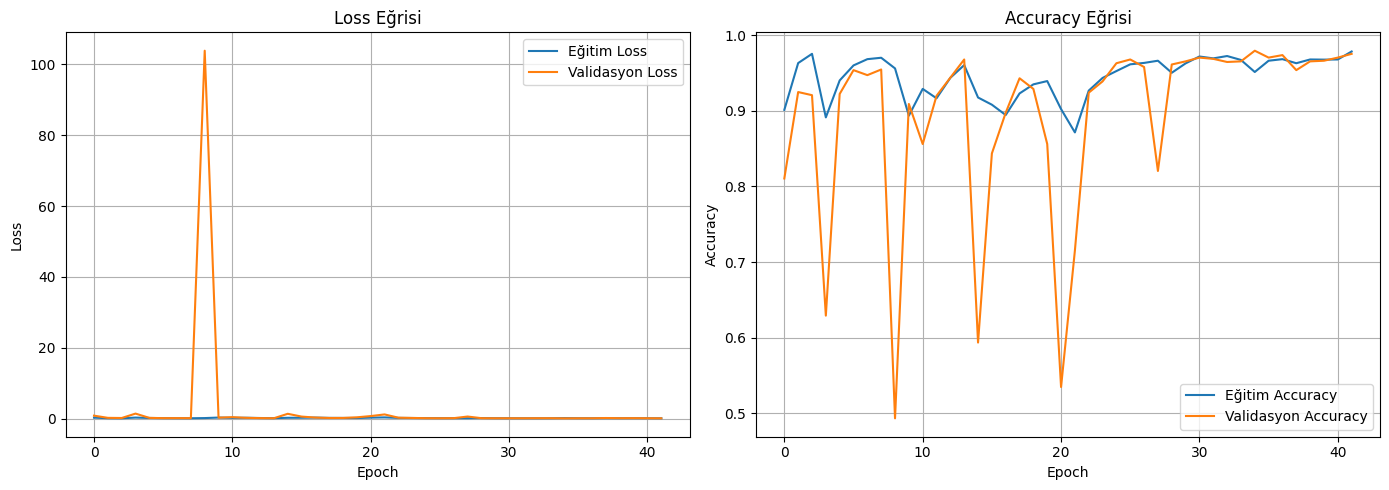

152/152 ━━━━━━━━━━━━━━━━━━━━ 748s 5s/step - accuracy: 0.9775 - loss: 0.0783 - val_accuracy: 0.9752 - val_loss: 0.0713 - learning_rate: 1.0000e-04
Epoch 43/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9760 - loss: 0.0771

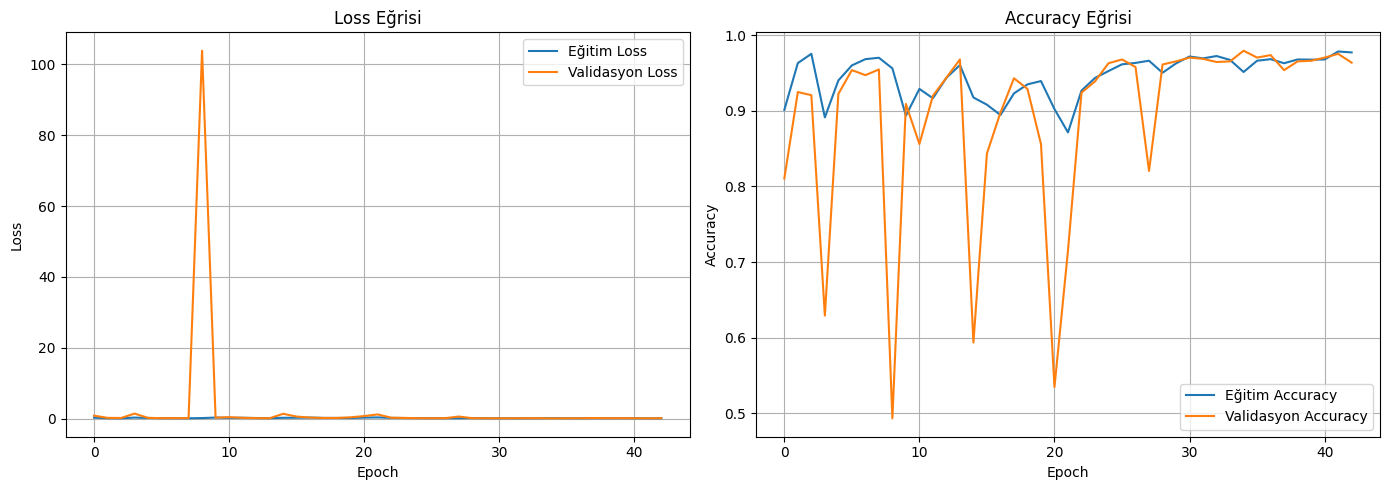

152/152 ━━━━━━━━━━━━━━━━━━━━ 706s 5s/step - accuracy: 0.9760 - loss: 0.0771 - val_accuracy: 0.9636 - val_loss: 0.1031 - learning_rate: 1.0000e-04
Epoch 44/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9771 - loss: 0.0702

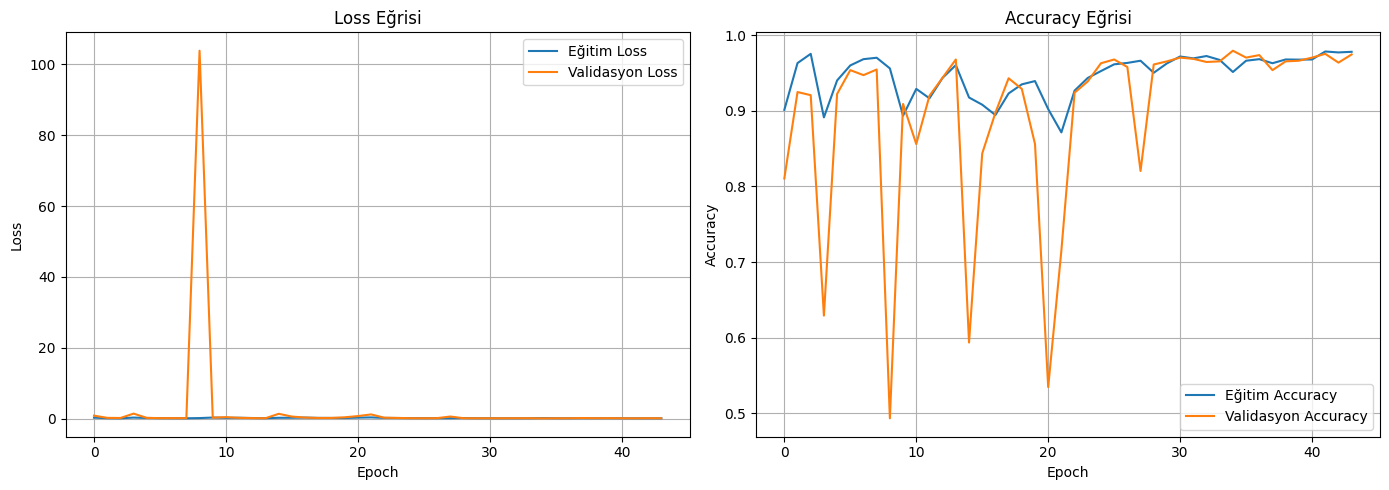

152/152 ━━━━━━━━━━━━━━━━━━━━ 701s 5s/step - accuracy: 0.9771 - loss: 0.0702 - val_accuracy: 0.9743 - val_loss: 0.0765 - learning_rate: 1.0000e-04
Epoch 45/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9805 - loss: 0.0624

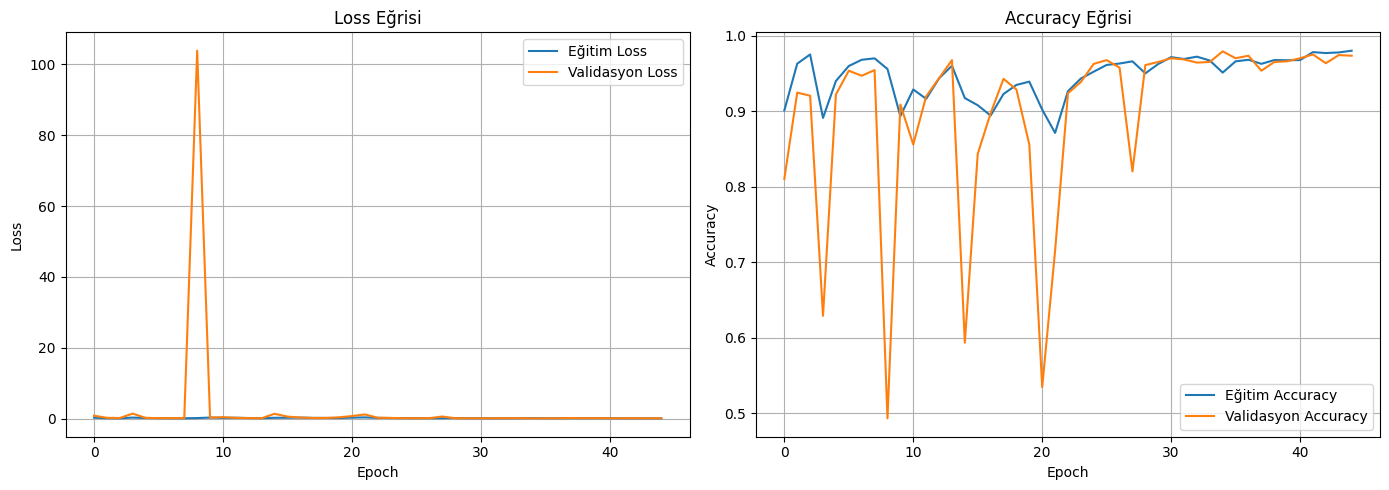

152/152 ━━━━━━━━━━━━━━━━━━━━ 666s 4s/step - accuracy: 0.9805 - loss: 0.0624 - val_accuracy: 0.9735 - val_loss: 0.0898 - learning_rate: 1.0000e-04
Epoch 46/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9773 - loss: 0.0703

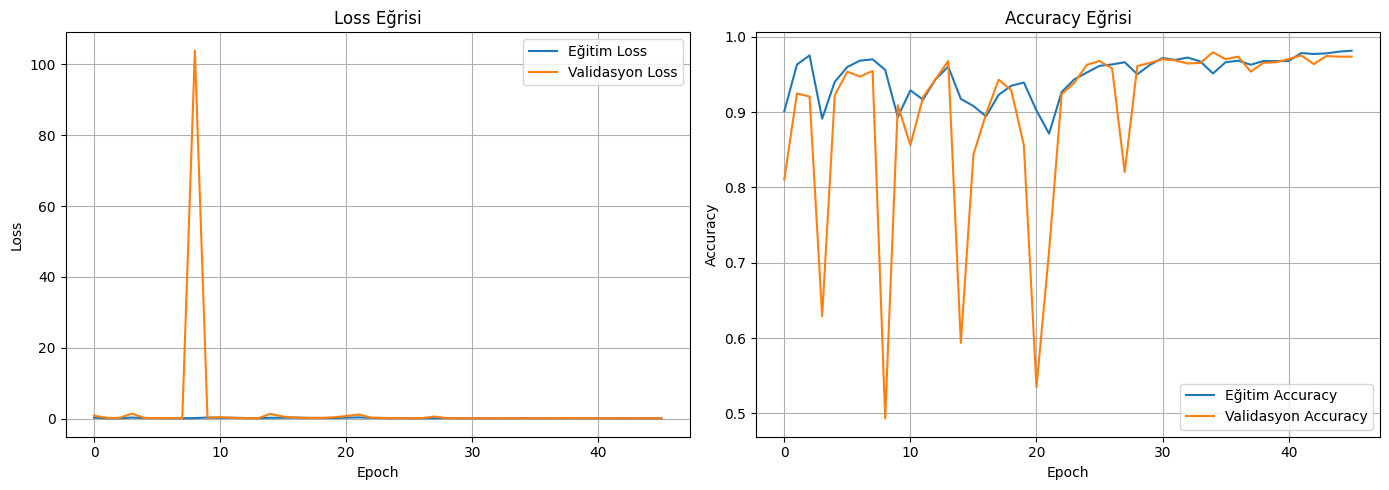

152/152 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9774 - loss: 0.0703 - val_accuracy: 0.9735 - val_loss: 0.0791 - learning_rate: 1.0000e-05
Epoch 47/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9820 - loss: 0.0595

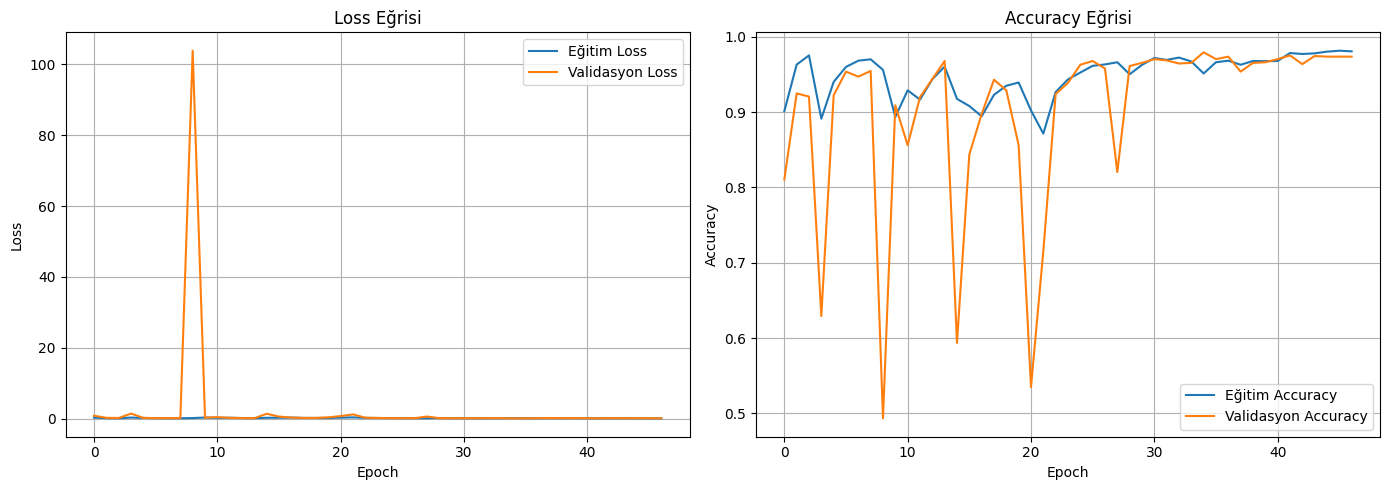

152/152 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9819 - loss: 0.0595 - val_accuracy: 0.9735 - val_loss: 0.0796 - learning_rate: 1.0000e-05
Epoch 48/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9870 - loss: 0.0439

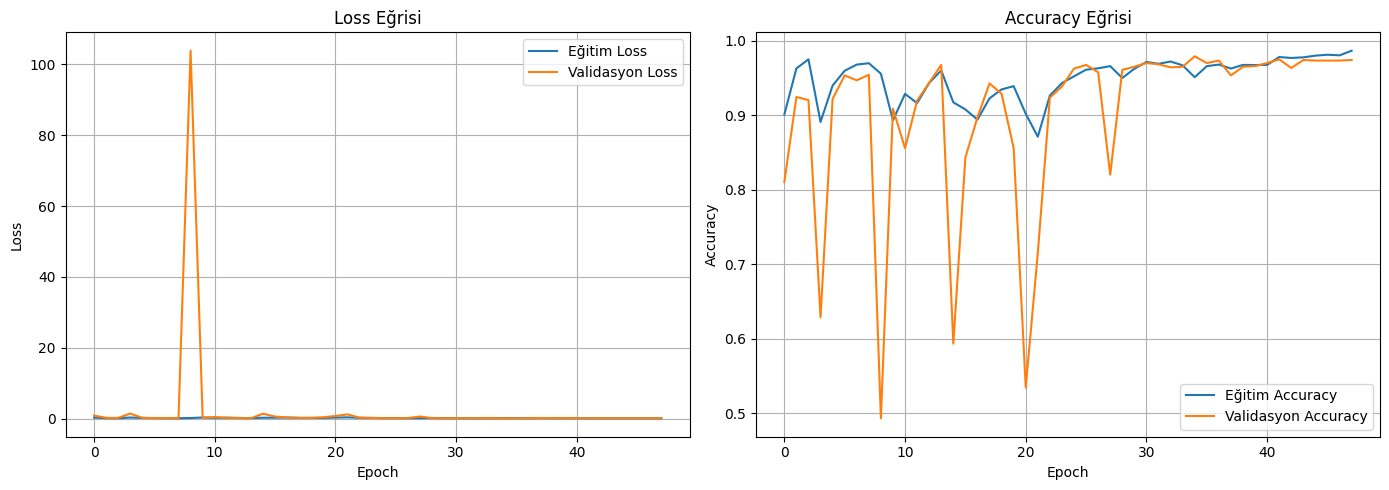

152/152 ━━━━━━━━━━━━━━━━━━━━ 659s 4s/step - accuracy: 0.9870 - loss: 0.0439 - val_accuracy: 0.9743 - val_loss: 0.0772 - learning_rate: 1.0000e-05
Epoch 49/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9810 - loss: 0.0536

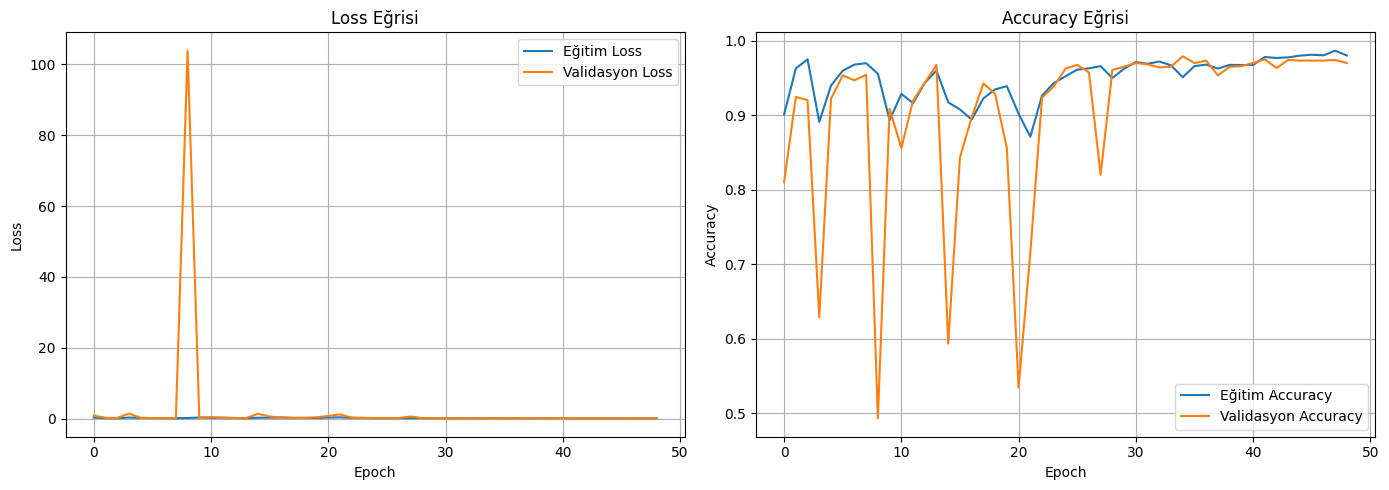

152/152 ━━━━━━━━━━━━━━━━━━━━ 659s 4s/step - accuracy: 0.9810 - loss: 0.0536 - val_accuracy: 0.9702 - val_loss: 0.0889 - learning_rate: 1.0000e-05
Epoch 50/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9794 - loss: 0.0576

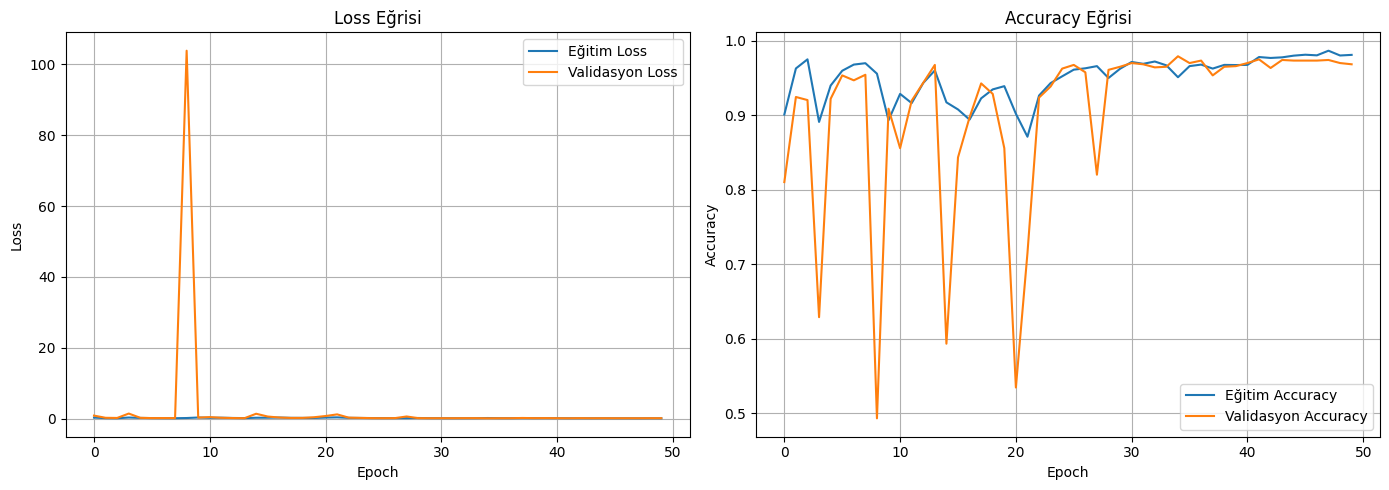

152/152 ━━━━━━━━━━━━━━━━━━━━ 662s 4s/step - accuracy: 0.9794 - loss: 0.0576 - val_accuracy: 0.9685 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 51/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9788 - loss: 0.0678

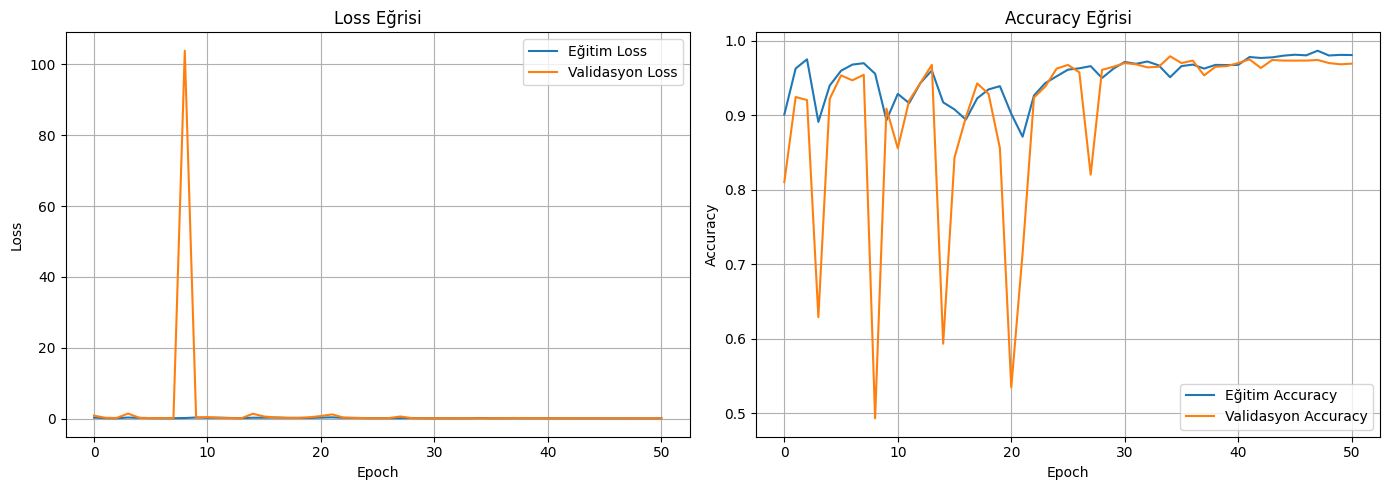

152/152 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9788 - loss: 0.0678 - val_accuracy: 0.9694 - val_loss: 0.0884 - learning_rate: 1.0000e-05
Epoch 52/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9866 - loss: 0.0496

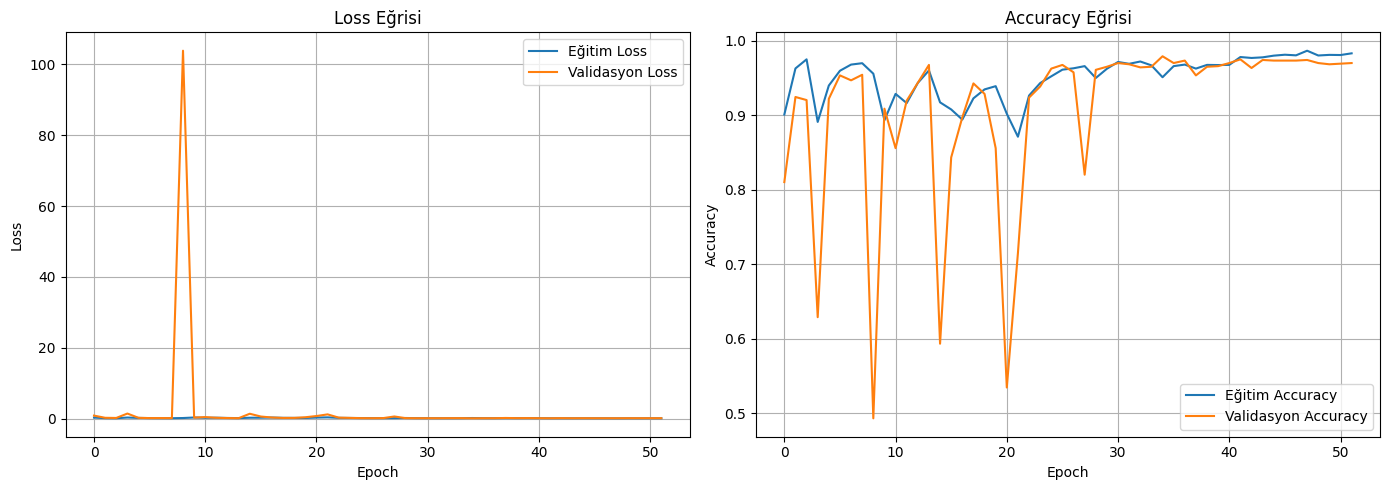

152/152 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9866 - loss: 0.0497 - val_accuracy: 0.9702 - val_loss: 0.0884 - learning_rate: 1.0000e-05
Epoch 53/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9841 - loss: 0.0513

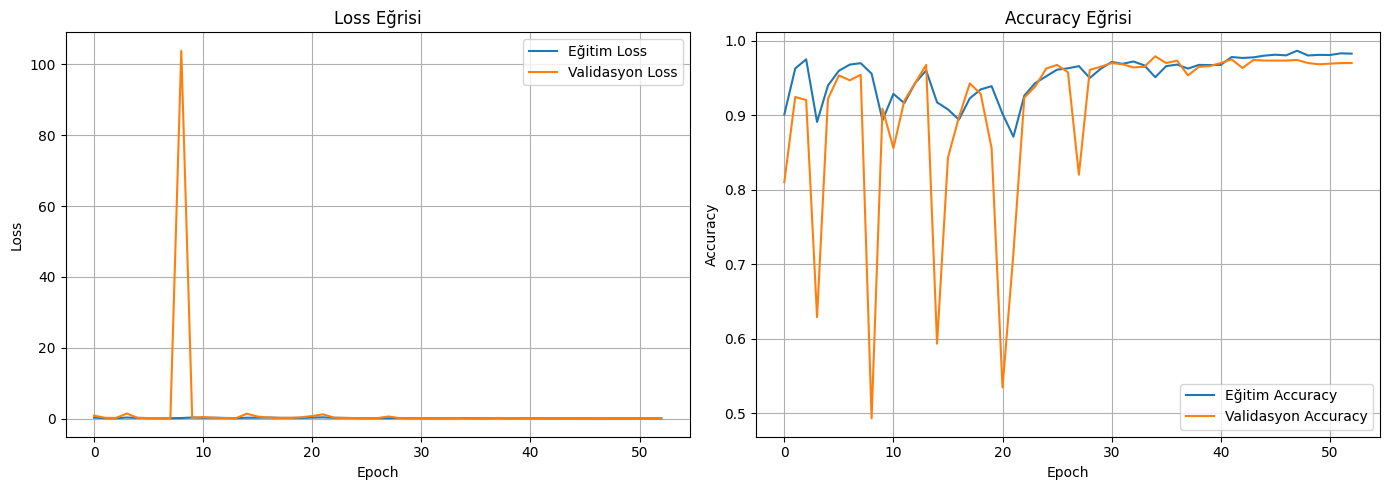

152/152 ━━━━━━━━━━━━━━━━━━━━ 663s 4s/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9702 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 54/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9803 - loss: 0.0594

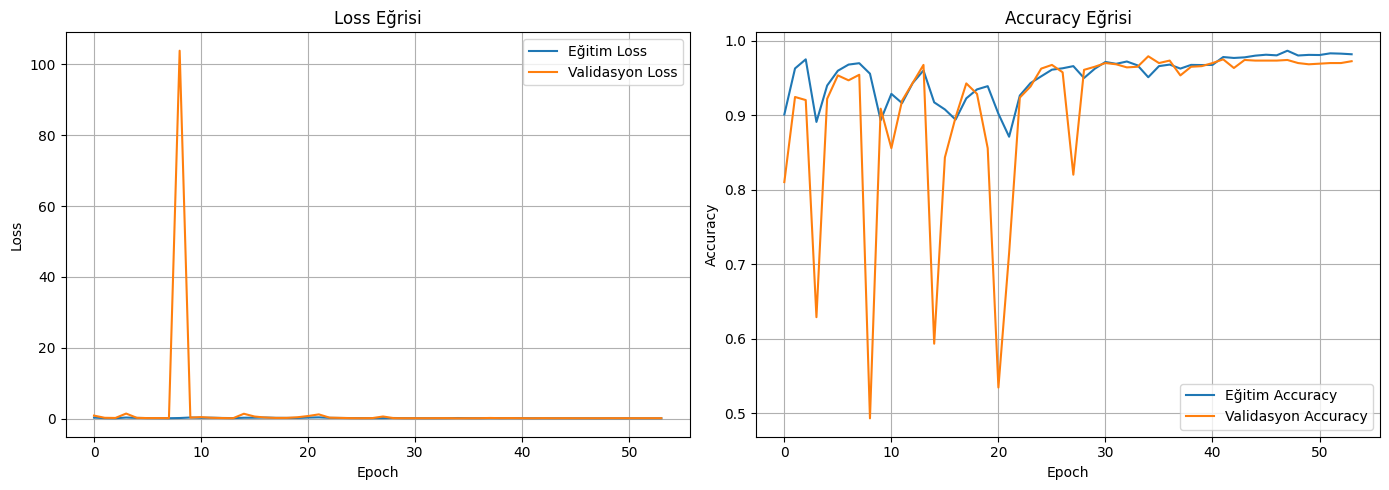

152/152 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9803 - loss: 0.0593 - val_accuracy: 0.9727 - val_loss: 0.0883 - learning_rate: 1.0000e-05
Epoch 55/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9868 - loss: 0.0487

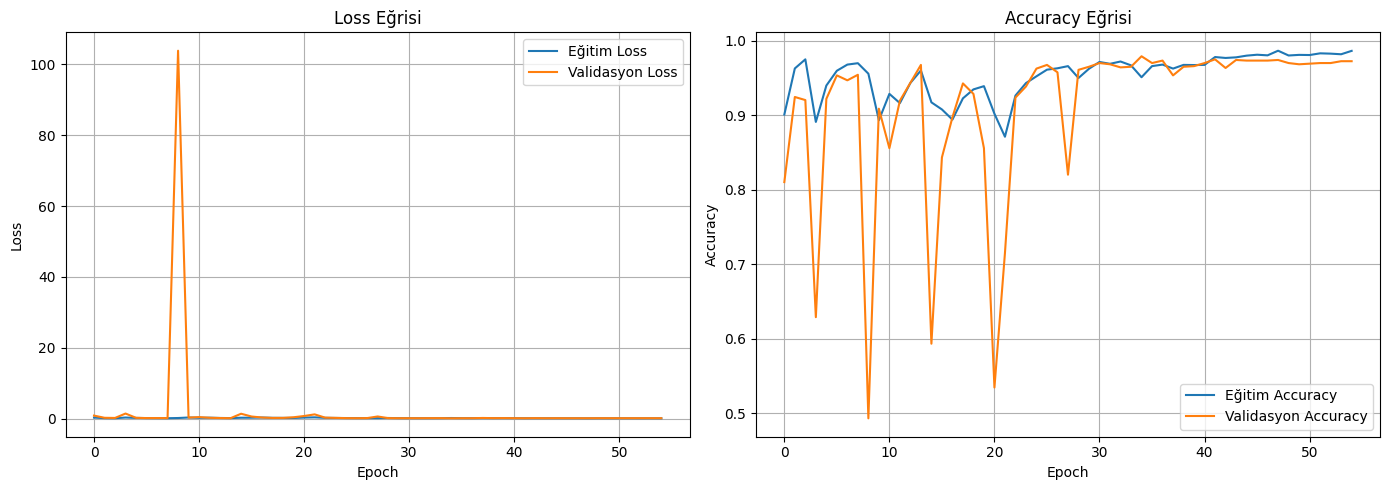

152/152 ━━━━━━━━━━━━━━━━━━━━ 665s 4s/step - accuracy: 0.9868 - loss: 0.0487 - val_accuracy: 0.9727 - val_loss: 0.0848 - learning_rate: 1.0000e-05
Epoch 56/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9829 - loss: 0.0523

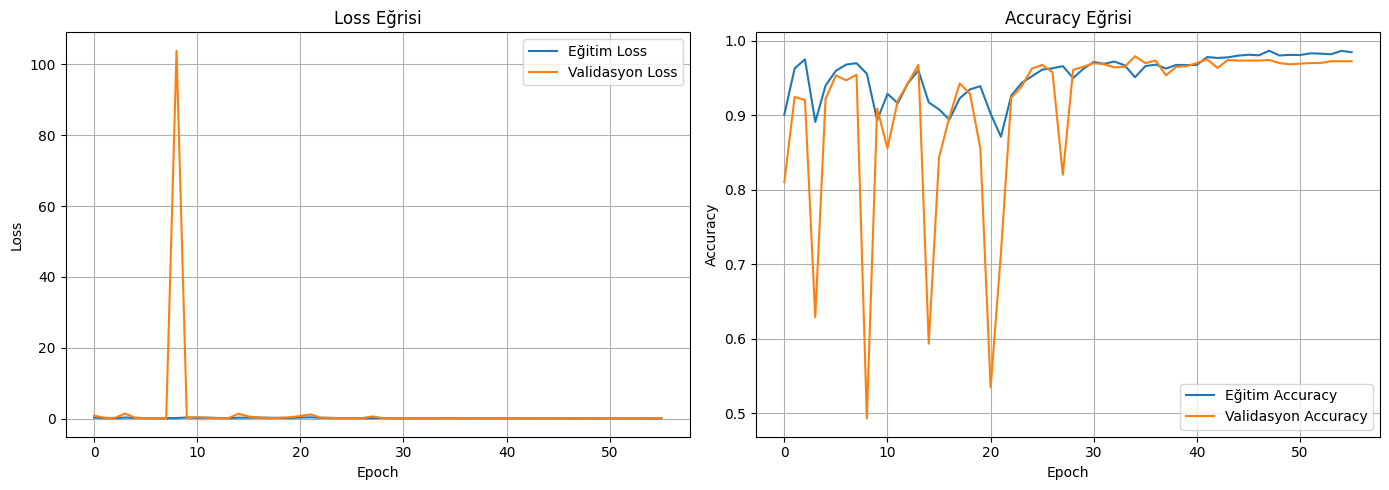

152/152 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9829 - loss: 0.0523 - val_accuracy: 0.9727 - val_loss: 0.0834 - learning_rate: 1.0000e-06
Epoch 57/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9830 - loss: 0.0553

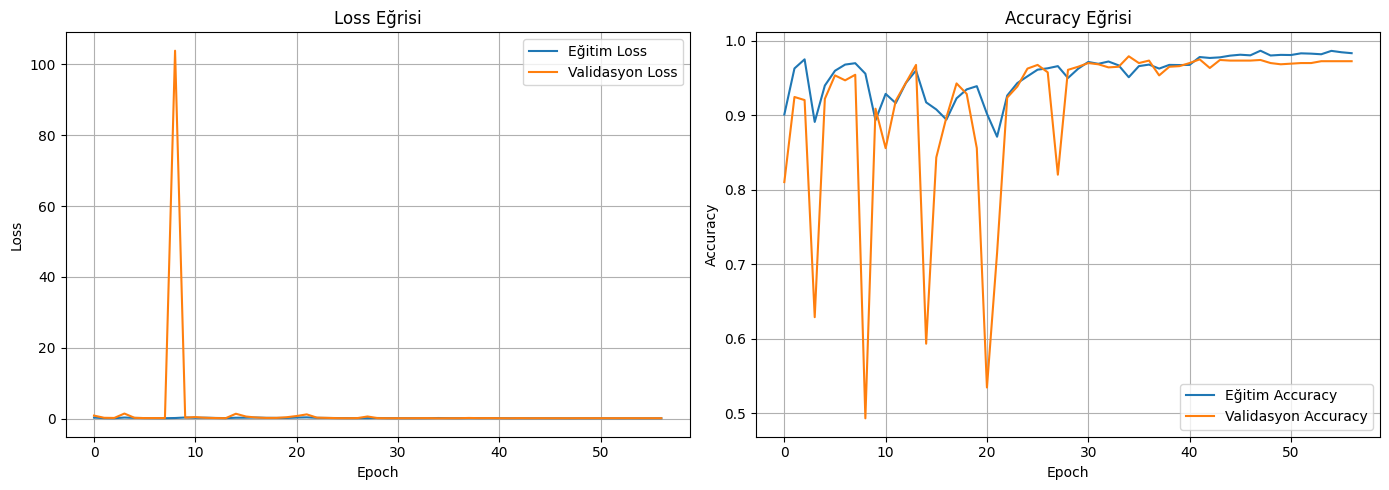

152/152 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9830 - loss: 0.0553 - val_accuracy: 0.9727 - val_loss: 0.0832 - learning_rate: 1.0000e-06
Epoch 58/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9843 - loss: 0.0536

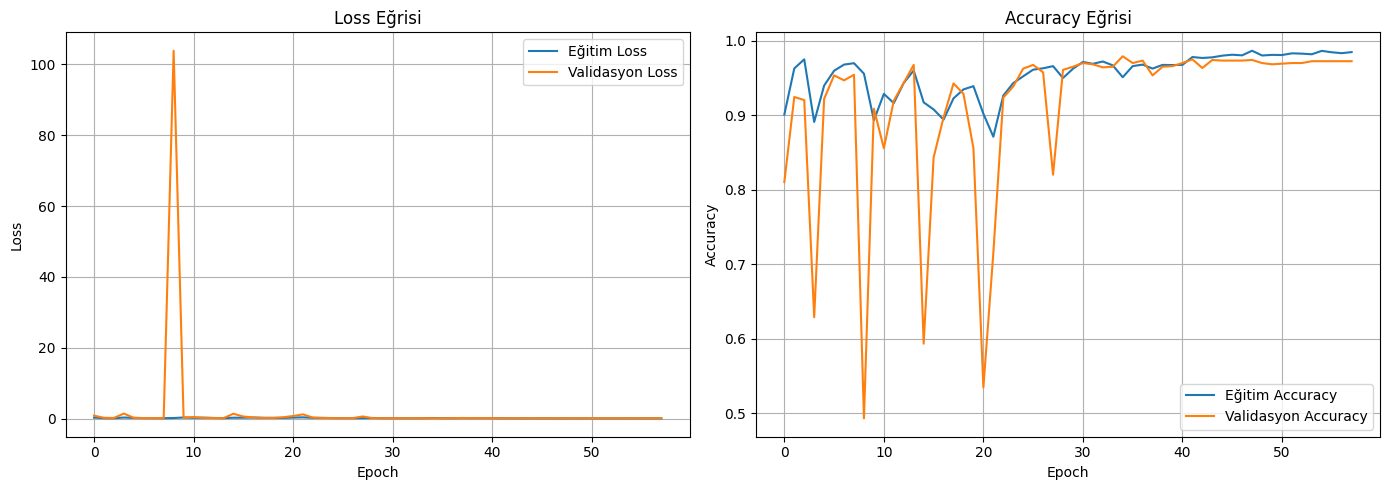

152/152 ━━━━━━━━━━━━━━━━━━━━ 665s 4s/step - accuracy: 0.9843 - loss: 0.0536 - val_accuracy: 0.9727 - val_loss: 0.0827 - learning_rate: 1.0000e-06
Epoch 59/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9802 - loss: 0.0612

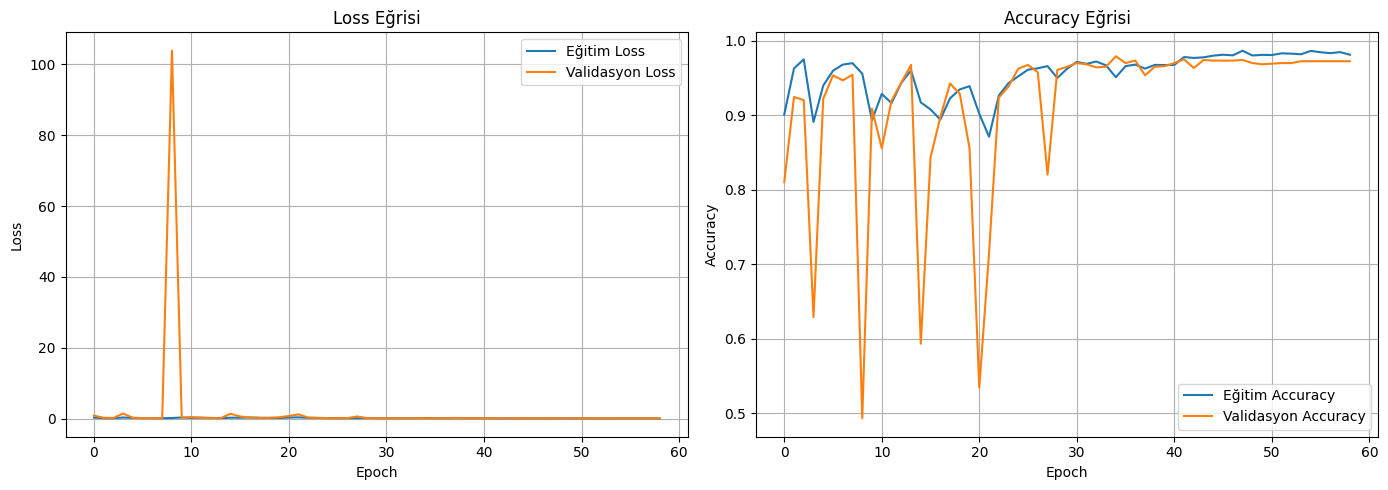

152/152 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9802 - loss: 0.0612 - val_accuracy: 0.9727 - val_loss: 0.0832 - learning_rate: 1.0000e-06
Epoch 60/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9847 - loss: 0.0501

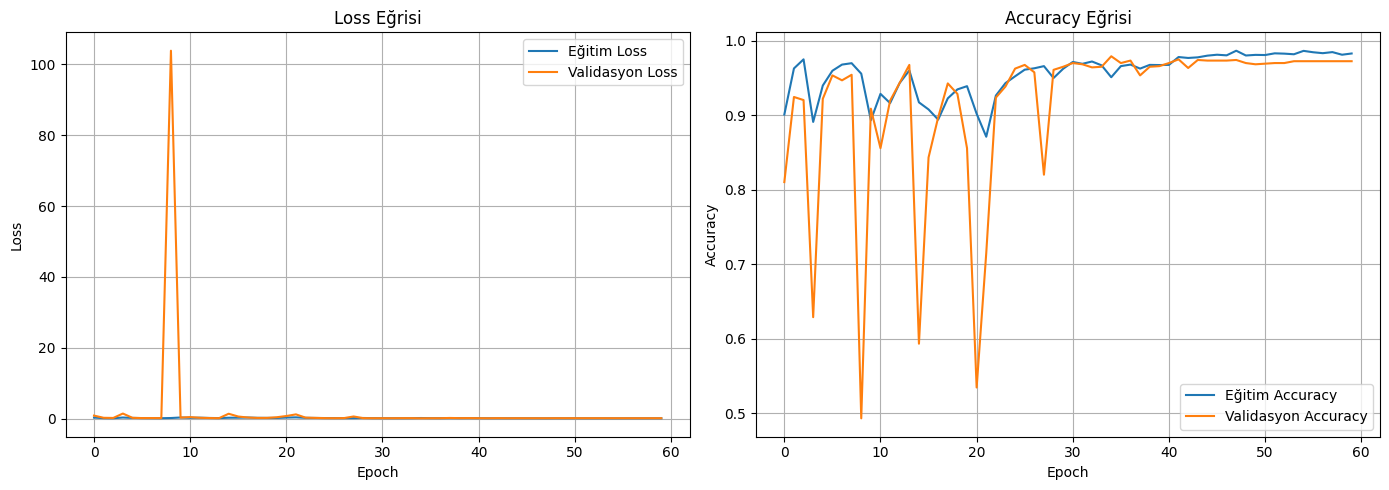

152/152 ━━━━━━━━━━━━━━━━━━━━ 662s 4s/step - accuracy: 0.9847 - loss: 0.0501 - val_accuracy: 0.9727 - val_loss: 0.0839 - learning_rate: 1.0000e-06


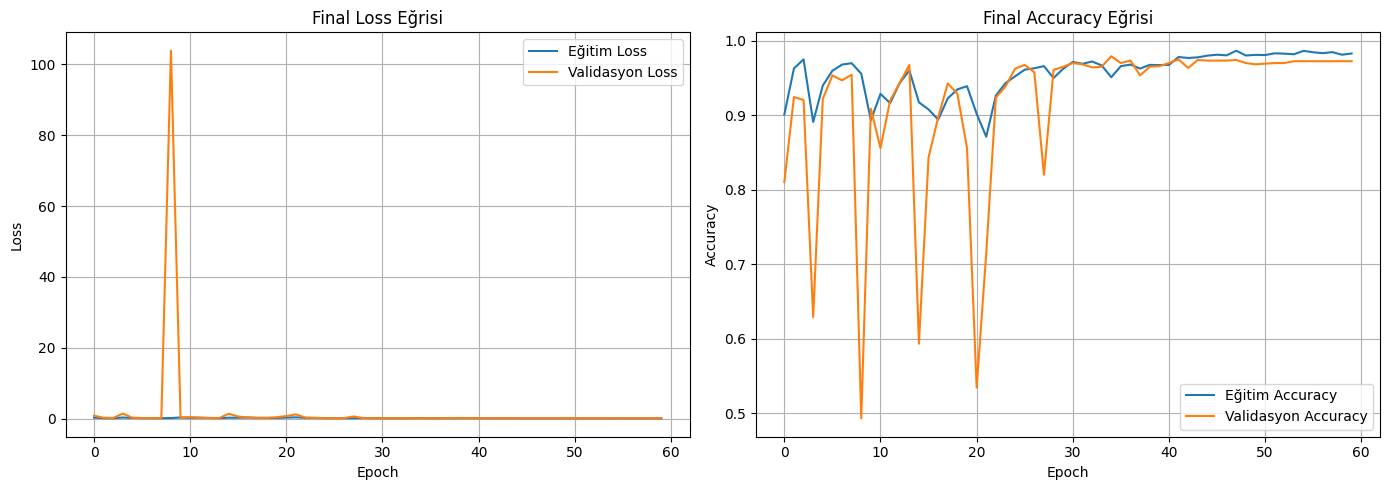

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

class LivePlotCallback(Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.accuracies = []
        self.val_accuracies = []

    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.accuracies.append(logs.get('accuracy'))
        self.val_accuracies.append(logs.get('val_accuracy'))

        plt.figure(figsize=(14,5))

        plt.subplot(1,2,1)
        plt.plot(self.losses, label='Eğitim Loss')
        plt.plot(self.val_losses, label='Validasyon Loss')
        plt.title('Loss Eğrisi')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()

        plt.subplot(1,2,2)
        plt.plot(self.accuracies, label='Eğitim Accuracy')
        plt.plot(self.val_accuracies, label='Validasyon Accuracy')
        plt.title('Accuracy Eğrisi')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()
        plt.pause(0.001)

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10)
live_plot = LivePlotCallback()

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, live_plot]
)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Validasyon Loss')
plt.title('Final Loss Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Validasyon Accuracy')
plt.title('Final Accuracy Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [14]:
model.save("bestModel.h5")

1511/1511 ━━━━━━━━━━━━━━━━━━━━ 115s 74ms/step


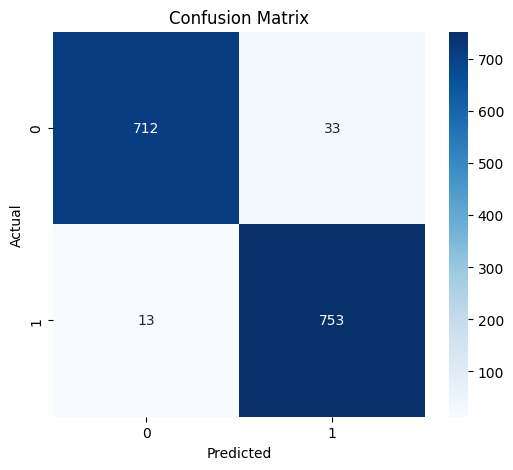

Classification Report:
              precision    recall  f1-score   support

   with_mask       0.98      0.96      0.97       745
without_mask       0.96      0.98      0.97       766

    accuracy                           0.97      1511
   macro avg       0.97      0.97      0.97      1511
weighted avg       0.97      0.97      0.97      1511



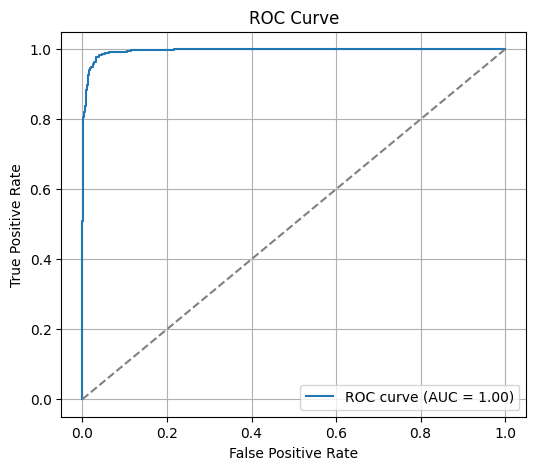

AUC Skoru: 0.9955
Specificity: 0.9557


In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

model = load_model("bestModel.h5")

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

if predictions.shape[1] == 2:
    fpr, tpr, thresholds = roc_curve(y_true, predictions[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()
    print(f"AUC Skoru: {roc_auc:.4f}")

if cm.shape == (2, 2):  
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    print(f"Specificity: {specificity:.4f}")


In [15]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.9695565850430179
Precision: 0.9580152671755725
Recall: 0.9830287206266318
F1 Score: 0.970360824742268


Sınıf: with_mask - 745 görsel
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


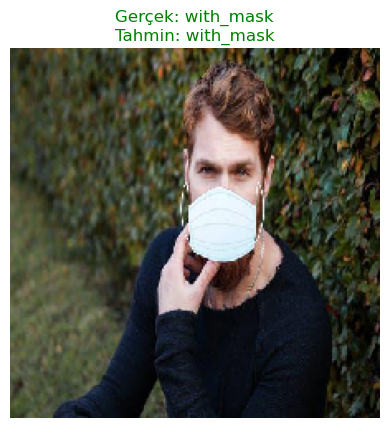

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


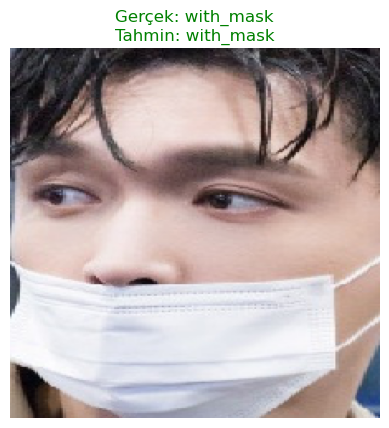

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


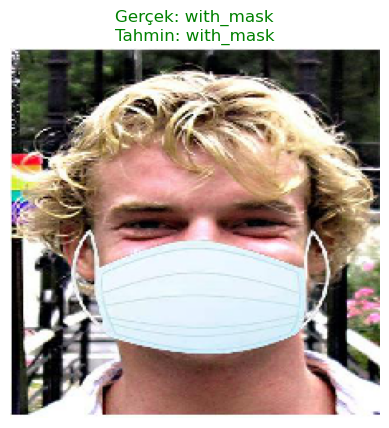

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


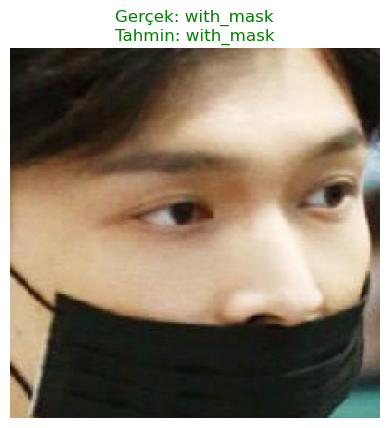

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


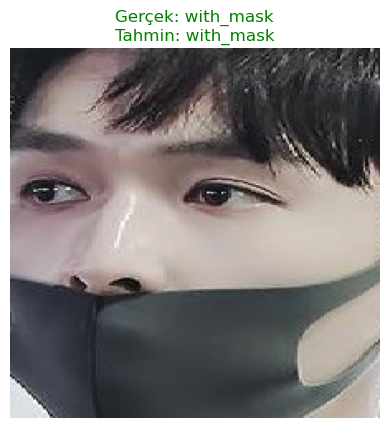

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


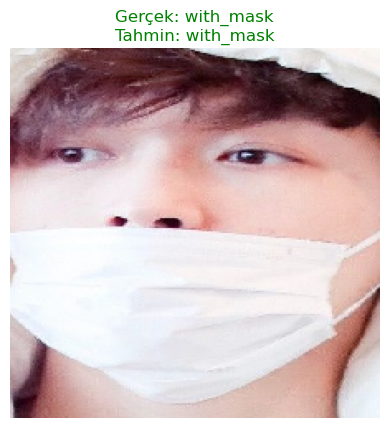

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


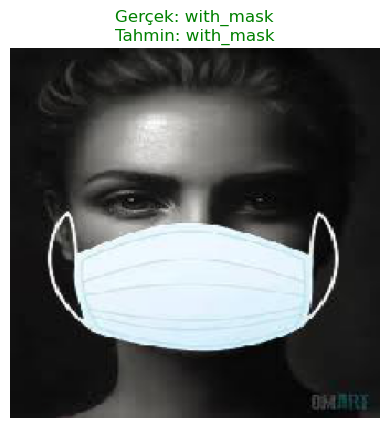

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


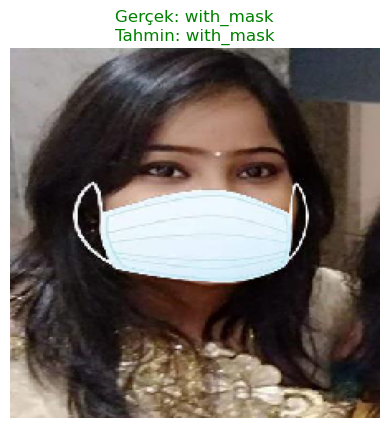

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


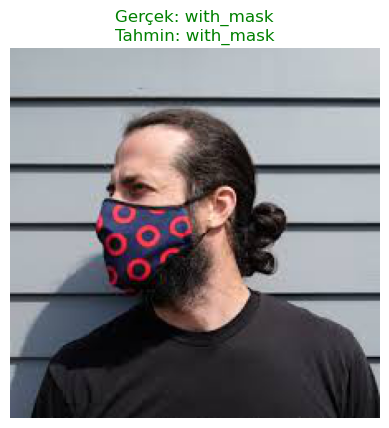

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


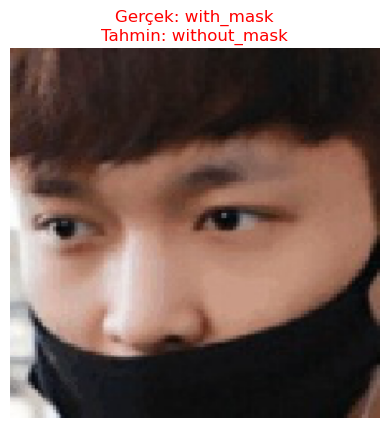

Sınıf: without_mask - 766 görsel
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


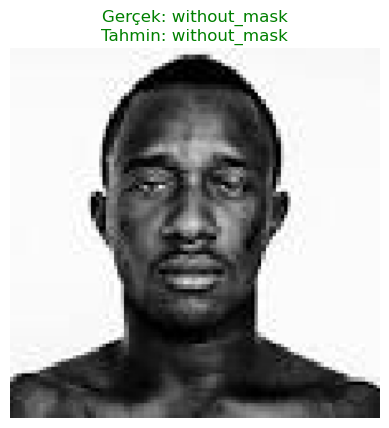

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


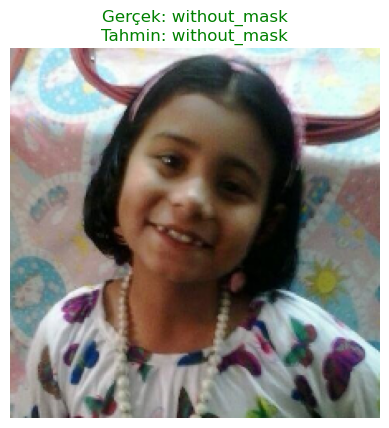

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


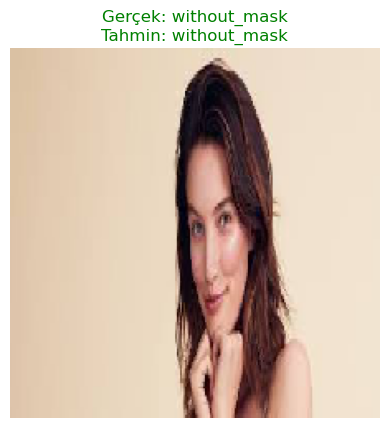

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


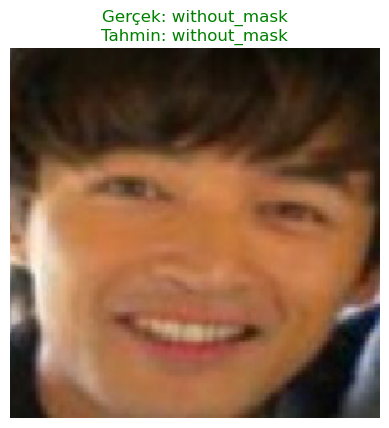

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


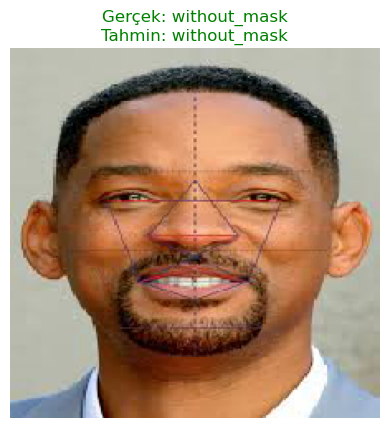

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


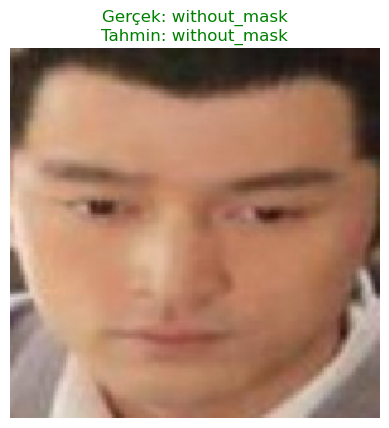

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


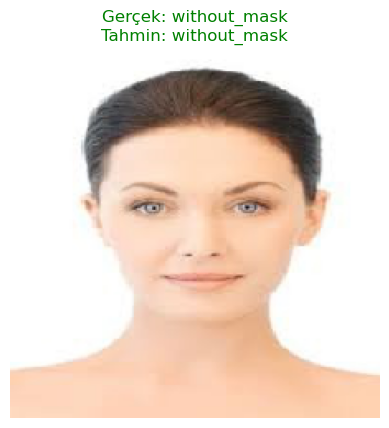

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


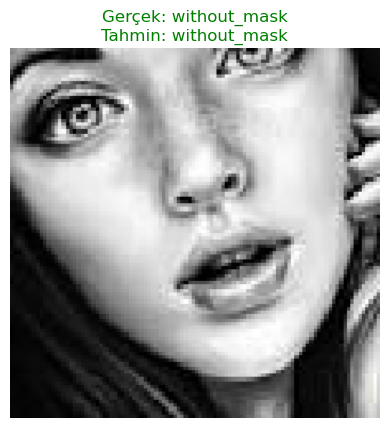

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


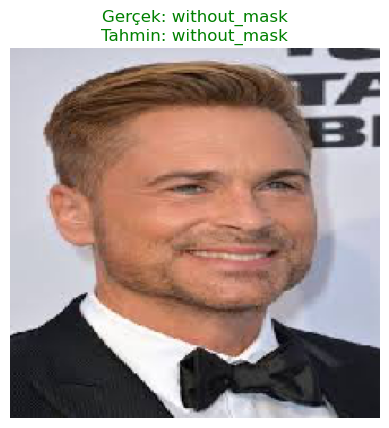

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


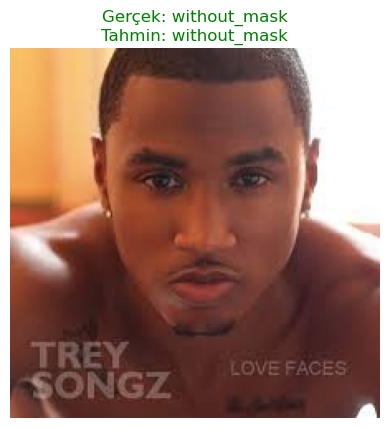

In [ ]:
model = load_model("bestModel.h5")

class_names = ['with_mask', 'without_mask']

test_dir = "Test"
img_size = (224, 224)

for class_label in class_names:
    folder_path = os.path.join(test_dir, class_label)
    file_list = os.listdir(folder_path)

    print(f"Sınıf: {class_label} - {len(file_list)} görsel")

    for file_name in file_list[:10]: 
        img_path = os.path.join(folder_path, file_name)

        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)
        predicted_index = np.argmax(prediction)
        predicted_class = class_names[predicted_index]

        is_correct = predicted_class == class_label
        color = 'green' if is_correct else 'red'

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Gerçek: {class_label}\nTahmin: {predicted_class}", color=color)
        plt.show()
